## Library yang digunakan

Output lama dicadangkan di `reports/notebook_backups/ai_1_nlu_v3_600_before_standalone_1790235729387.ipynb`.

In [1]:
# Library standar Python: file, konfigurasi, waktu, dan memori.
import gc
import json
import math
import platform
import tempfile
import time
from copy import deepcopy
from pathlib import Path
from time import perf_counter

# Pengolahan data, visualisasi, dan penyimpanan model.
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Model klasik, ekstraksi fitur, pencarian parameter, dan evaluasi.
import optuna
import sklearn
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
)
from sklearn.model_selection import (
    GridSearchCV, ParameterGrid, StratifiedKFold, cross_val_score, train_test_split,
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

# Dataset, training, dan inferensi Transformer/IndoBERT.
import torch
import transformers
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)


c:\Users\andyc\Documents\a_skripsi\training\prethesis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## EDA



In [2]:
# Menentukan lokasi file dataset untuk EDA.
DATASET_PATH = Path("data/dataset_final3.csv")


In [3]:
# Membaca CSV, membersihkan chat dan label, lalu mengembalikan data bersih serta laporan kualitasnya.
def load_clean_nlu_dataset(dataset_path):

    # Menghentikan proses dengan pesan jelas jika file dataset tidak ditemukan.
    path = Path(dataset_path)
    if not path.is_file():
        raise FileNotFoundError(f"Dataset tidak ditemukan: {path}")

    # Membaca isi CSV ke tabel pandas.
    raw = pd.read_csv(path)

    # Mencatat jumlah baris awal dan nilai kosong sebelum data dibersihkan.
    report = {
        "dataset_path": str(path),
        "rows_raw": len(raw),
        "missing_cells_raw": raw[["teks_chat", "label_intent"]].isna().sum().to_dict(),    
    }


    # Mengambil kolom chat dan label, membuang nilai kosong, merapikan spasi, serta menyeragamkan label ke huruf kecil.
    clean = raw[["teks_chat", "label_intent"]].dropna().copy()
    clean["teks_chat"] = clean["teks_chat"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    clean["label_intent"] = clean["label_intent"].astype(str).str.strip().str.lower()
    empty_mask = (clean["teks_chat"] == "") | (clean["label_intent"] == "")


    # Menghitung lalu menghapus baris yang chat atau labelnya menjadi teks kosong setelah dirapikan.
    report["empty_rows_removed"] = int(empty_mask.sum())
    clean = clean.loc[~empty_mask].copy()

    # Menghitung lalu menghapus pasangan chat dan label yang sama persis.
    report["exact_duplicates_removed"] = int(clean.duplicated(["teks_chat", "label_intent"]).sum())
    clean = clean.drop_duplicates(["teks_chat", "label_intent"]).copy()

    # Mencari chat yang memiliki lebih dari satu label dan menghapus semua baris chat tersebut jika ditemukan.
    label_count_per_text = clean.groupby("teks_chat")["label_intent"].nunique()
    conflicting_texts = label_count_per_text[label_count_per_text > 1].index
    report["conflicting_texts_removed"] = int(len(conflicting_texts))
    if len(conflicting_texts):
        clean = clean.loc[~clean["teks_chat"].isin(conflicting_texts)].copy()


    # Menghitung jumlah data tiap intent setelah pembersihan.
    class_counts = clean["label_intent"].value_counts().sort_index()

    # Melengkapi laporan dengan jumlah data bersih, jumlah intent, dan ukuran kelas.
    report.update(
        {
            "rows_clean": len(clean),
            "class_count": int(class_counts.size),
            "class_distribution": class_counts.to_dict(),
            "min_class_size": int(class_counts.min()),
            "max_class_size": int(class_counts.max()),
        }
    )

    # Mengembalikan data dengan indeks baru beserta laporan pembersihannya.
    return clean.reset_index(drop=True), report


In [4]:
# Menghitung panjang chat dan statistik per intent untuk melengkapi laporan EDA.
def build_eda_summary(dataset_path):

    # Mengambil data bersih dan laporan pembersihan.
    clean, report = load_clean_nlu_dataset(dataset_path)

    # Menghitung jumlah karakter dan kata pada setiap chat.
    lengths = clean["teks_chat"].str.len()
    words = clean["teks_chat"].str.split().str.len()

    # Mengelompokkan chat per intent untuk menghitung jumlah dan rata-rata panjangnya.
    length_by_intent = (
        pd.DataFrame({"label_intent": clean["label_intent"], "karakter": lengths, "kata": words})
        .groupby("label_intent")
        .agg(jumlah=("kata", "size"), rata_kata=("kata", "mean"), median_kata=("kata", "median"), rata_karakter=("karakter", "mean"))
        .round(2)
        .sort_index()
    )

    # Menambahkan jumlah chat pendek serta rata-rata dan median jumlah kata ke laporan.
    report["short_chat_under_3_words"] = int((words < 3).sum())
    report["average_words"] = round(float(words.mean()), 2)
    report["median_words"] = round(float(words.median()), 2)
    return clean, report, length_by_intent


In [5]:
# Menampilkan laporan kualitas data, statistik panjang chat, dan grafik distribusi intent.
def run_nlu_eda(dataset_path, plot = True):

    # Mengambil statistik EDA yang akan ditampilkan.
    clean, report, length_by_intent = build_eda_summary(dataset_path)

    # Menampilkan laporan kualitas, distribusi intent, dan panjang chat dalam bentuk teks.
    print("=" * 58)
    print("EDA DATASET NLU HOSTAGE")
    print("=" * 58)
    print(f"Dataset                 : {report['dataset_path']}")
    print(f"Baris mentah / bersih   : {report['rows_raw']} / {report['rows_clean']}")
    print(f"Nilai kosong            : {report['missing_cells_raw']}")
    print(f"Duplikat tepat dihapus  : {report['exact_duplicates_removed']}")
    print(f"Teks konflik dihapus    : {report['conflicting_texts_removed']}")
    print(f"Jumlah intent           : {report['class_count']}")
    print(f"Ukuran kelas min--maks  : {report['min_class_size']}--{report['max_class_size']}")
    print(f"Rata-rata kata/chat     : {report['average_words']}")
    print(f"Chat < 3 kata           : {report['short_chat_under_3_words']}")
    print("\nDistribusi intent:")
    print(pd.Series(report["class_distribution"], name="jumlah"))
    print("\nStatistik panjang chat per intent:")
    print(length_by_intent)

    # Jika plot diaktifkan, menampilkan grafik batang jumlah chat pada setiap intent.
    if plot:
        distribution = pd.Series(report["class_distribution"]).sort_values(ascending=False)
        ax = distribution.plot.bar(figsize=(10, 4), color="#4C78A8", title="Distribusi data per intent")
        ax.set_xlabel("Intent")
        ax.set_ylabel("Jumlah chat")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    return clean, report


# Menjalankan EDA menggunakan lokasi dataset yang sudah diatur di atas.
def run_eda(plot=True):
    return run_nlu_eda(DATASET_PATH, plot=plot)


### Tampilkan distribusi dan kualitas data


EDA DATASET NLU HOSTAGE
Dataset                 : data\dataset_final3.csv
Baris mentah / bersih   : 5615 / 5611
Nilai kosong            : {'teks_chat': 0, 'label_intent': 0}
Duplikat tepat dihapus  : 4
Teks konflik dihapus    : 0
Jumlah intent           : 3
Ukuran kelas min--maks  : 942--2561
Rata-rata kata/chat     : 11.76
Chat < 3 kata           : 2

Distribusi intent:
defend      942
neutral    2108
offend     2561
Name: jumlah, dtype: int64

Statistik panjang chat per intent:
              jumlah  rata_kata  median_kata  rata_karakter
label_intent                                               
defend           942      11.95         12.0          71.95
neutral         2108       9.43          9.0          57.41
offend          2561      13.61         13.0          83.29


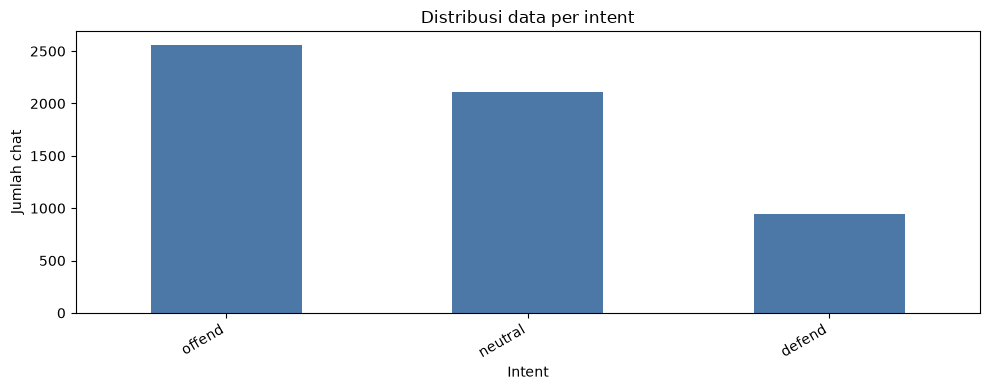

In [6]:
data_bersih, laporan_eda = run_eda()


## Split, Evaluasi, Penyimpanan Model, dan Prediksi


In [7]:
# Menetapkan seed untuk pembagian data, cross-validation, dan training yang konsisten.
RANDOM_STATE = 42

# Folder penyimpanan model hasil training.
MODEL_DIR = Path("models/notebook_standalone")


In [8]:
# Membagi data bersih menjadi data latih dan uji dengan proporsi intent tetap terwakili.
def _split_dataset(dataset_path, test_size = 0.2):
    data, data_report = load_clean_nlu_dataset(dataset_path)
    x_train, x_test, y_train, y_test = train_test_split(
        data["teks_chat"],
        data["label_intent"],
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=data["label_intent"],
    )
    return x_train, x_test, y_train, y_test, data_report


In [9]:
# -----------------------------------------------------------------------------
# Evaluasi, penyimpanan model, dan prediksi model klasik.
# -----------------------------------------------------------------------------

# Mengukur accuracy dan F1 model pada data uji serta menampilkan laporan tiap kelas.
def _evaluate(model, x_test, y_test, title):

    # Memprediksi data uji lalu menghitung ukuran ketepatan model.
    y_pred = model.predict(x_test)
    metrics = {
        "accuracy": round(float(accuracy_score(y_test, y_pred)), 4),
        "f1_macro": round(float(f1_score(y_test, y_pred, average="macro", zero_division=0)), 4),
        "f1_weighted": round(float(f1_score(y_test, y_pred, average="weighted", zero_division=0)), 4),
        "classification_report": classification_report(y_test, y_pred, zero_division=0),
    }

    # Menampilkan metrik keseluruhan dan laporan per kelas.
    print(f"\n--- Evaluasi {title} (holdout test set) ---")
    print(f"Accuracy    : {metrics['accuracy']:.4f}")
    print(f"Macro F1    : {metrics['f1_macro']:.4f}")
    print(f"Weighted F1 : {metrics['f1_weighted']:.4f}")
    print(metrics["classification_report"])
    return metrics


In [10]:
# Menyimpan model klasik ke file agar dapat dipakai lagi untuk prediksi.
def _save_sklearn_model(model, model_dir, filename):
    output_dir = Path(model_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    model_path = output_dir / filename
    joblib.dump(model, model_path)
    print(f"Model tersimpan: {model_path}")
    return model_path


In [11]:
# Memuat model klasik pilihan, lalu mengembalikan prediksi intent dan confidence untuk satu chat.
def predict_intent(text, model_dir, filename):
    """Prediksi label dan confidence dari nama file model yang disebutkan eksplisit."""

    # Memastikan file model tersedia sebelum dimuat.

    model_path = Path(model_dir) / filename
    if not model_path.is_file():
        raise FileNotFoundError(f"File model tidak ditemukan: {model_path}. Periksa nama file dan folder model yang dipakai.")

    # Memuat model tersimpan dan memprediksi label chat.
    model = joblib.load(model_path)
    predicted = str(model.predict([str(text)])[0])

    # Menghitung confidence dari probabilitas jika tersedia, atau dari skor keputusan; jika keduanya tidak ada, memakai NaN.
    if hasattr(model, "predict_proba"):
        confidence = float(np.max(model.predict_proba([str(text)])[0]) * 100)
    elif hasattr(model, "decision_function"):
        scores = np.asarray(model.decision_function([str(text)]), dtype=float).reshape(1, -1)
        probabilities = np.exp(scores - scores.max(axis=1, keepdims=True))
        probabilities /= probabilities.sum(axis=1, keepdims=True)
        confidence = float(probabilities.max() * 100)
    else:
        confidence = float("nan")

    return predicted, round(confidence, 2)


In [12]:
# Mengemas model, metrik, laporan data, dan lokasi file dalam format hasil yang seragam.
def _result(
    model,
    metrics,
    report,
    model_path,
    **extra,
):
    """Samakan format hasil agar notebook dapat membandingkan semua model."""
    return {
        "model": model,
        "metrics": metrics,
        "data_report": report,
        "model_path": str(model_path),
        **extra,
    }


## Persiapan Model dan Tuning

Pengaturan CV, fitur TF-IDF, pilihan parameter, Grid Search, dan Optuna yang dipakai bersama oleh SVM dan Naive Bayes.


In [13]:
# Model klasik dijalankan pada CPU.
CLASSICAL_DEVICE = "cpu"

# Jumlah fold untuk cross-validation saat tuning.
CV_FOLDS = 5

# Gunakan seluruh core CPU yang tersedia untuk CV paralel.
CV_N_JOBS = -1


In [14]:
# Batas trial dan aturan berhenti Optuna saat skor tidak membaik.
OPTUNA_MIN_TRIALS = 100

OPTUNA_PATIENCE = 30

OPTUNA_MIN_DELTA = 0.001

OPTUNA_MAX_TRIALS = 500

OPTUNA_TIMEOUT = None  # Bila diisi, timeout boleh menghentikan sebelum 100 trial.


In [15]:
# Membuat pengubah teks menjadi fitur TF-IDF untuk model baseline.
def _baseline_tfidf():
    """Fitur baseline tetap; kalibrasi SVM memakai pipeline lengkap."""
    return TfidfVectorizer(
        ngram_range=(1, 2), min_df=1, max_df=0.98,
        sublinear_tf=True, strip_accents="unicode",
    )


In [16]:
# Menyediakan pilihan parameter SVM atau Naive Bayes untuk Grid Search dan Optuna.
def _classical_search_spaces(model_kind):
    """Kembalikan grid baru agar mutasi satu eksperimen tidak mengubah lainnya."""
    common = {
        "tfidf__min_df": [1, 2],
        "tfidf__max_df": [0.95, 1.0],
        "tfidf__sublinear_tf": [True, False],
    }

    # Memilih ruang pencarian SVM, termasuk fitur kata atau karakter, nilai C, dan bobot kelas.
    if model_kind == "svm":
        return [
            {
                **deepcopy(common),
                "tfidf__analyzer": [analyzer],
                "tfidf__ngram_range": ngrams,
                "svm__C": list(SVM_C_VALUES),
                "svm__class_weight": [None, "balanced"],
            }
            for analyzer, ngrams in [
                ("word", [(1, 1), (1, 2), (1, 3)]),
                ("char_wb", [(3, 5), (3, 6)]),
            ]
        ]

    # Memilih ruang pencarian Naive Bayes, termasuk fitur kata, alpha, dan prior kelas.
    if model_kind == "nb":
        return [{
            **deepcopy(common),
            "tfidf__analyzer": ["word"],
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__use_idf": [True, False],
            "tfidf__norm": ["l2", "l1", None],
            "nb__alpha": list(NB_ALPHA_VALUES),
            "nb__fit_prior": [True, False],
        }]

    raise ValueError("model_kind harus 'svm' atau 'nb'.")


In [17]:
# Menyiapkan fold CV yang sama untuk semua kandidat dan 3 fold kalibrasi khusus SVM.
def _classical_cv(y_train, model_kind, cv_folds):
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    folds = list(cv.split(np.zeros(len(y_train)), y_train))
    calibration_folds = 3 if model_kind == "svm" else 0
    return folds, calibration_folds


In [18]:
# Mencoba semua kombinasi parameter dengan Grid Search, lalu mengevaluasi dan menyimpan model terbaik.
def _train_classical_grid(dataset_path, model_dir, filename, model_kind, cv_folds, n_jobs):
    """Coba seluruh grid pada train CV, refit pemenang, kemudian evaluasi test."""

    # Menyiapkan data, fold, pilihan parameter, dan folder hasil Grid Search.
    x_train, x_test, y_train, y_test, report = _split_dataset(dataset_path)
    folds, calibration_folds = _classical_cv(y_train, model_kind, cv_folds)
    spaces = _classical_search_spaces(model_kind)
    prefix = "estimator__" if model_kind == "svm" else ""
    grid = [{prefix + key: values for key, values in space.items()} for space in spaces]

    # Membuat pipeline di tempat kandidat dilatih agar alurnya mudah ditelusuri.
    if model_kind == "svm":
        model = _calibrated_linear_svm(1.0, None, calibration_folds)
    else:
        model = Pipeline([
            ("tfidf", TfidfVectorizer(strip_accents="unicode")),
            ("nb", MultinomialNB()),
        ])

    output_root = Path(model_dir) / "grid_results"
    output_root.mkdir(parents=True, exist_ok=True)
    run_dir = Path(tempfile.mkdtemp(prefix=f"{model_kind}_", dir=output_root))

    # Mencoba seluruh kombinasi dengan macro-F1 CV sebagai penentu model terbaik.
    search = GridSearchCV(
        model, grid, scoring="f1_macro", cv=folds, n_jobs=n_jobs,
        refit=True, verbose=1, error_score="raise", return_train_score=False,
    )
    started = perf_counter()
    search.fit(x_train, y_train)
    search_seconds = perf_counter() - started

    # Menyimpan hasil setiap kandidat dan mengambil parameter serta variasi skor kandidat terbaik.
    pd.DataFrame(search.cv_results_).to_csv(run_dir / "cv_results.csv", index=False)
    best = {key.removeprefix(prefix): value for key, value in search.best_params_.items()}
    cv_std = float(search.cv_results_["std_test_score"][search.best_index_])
    print("Parameter Grid Search terbaik:", best)
    print(f"Macro-F1 CV: {search.best_score_:.4f} +/- {cv_std:.4f}")

    # Tidak ada perubahan struktur estimator setelah pemilihan kandidat.
    model = search.best_estimator_
    metrics = _evaluate(model, x_test, y_test, f"{model_kind.upper()} Grid Search")
    path = _save_sklearn_model(model, model_dir, filename)

    # Merangkum konfigurasi, durasi, dan hasil evaluasi untuk laporan eksperimen.
    summary = {
        "method": "Grid Search", "model_kind": model_kind, "seed": RANDOM_STATE,
        "candidate_count": len(search.cv_results_["params"]),
        "cv_folds": len(folds), "calibration_folds": calibration_folds or None,
        "selection_metric": "cv_f1_macro", "test_used_for_selection": False,
        "best_params": best, "cv_f1_macro": float(search.best_score_), "cv_std": cv_std,
        "search_and_refit_seconds": search_seconds,
        "metrics": metrics, "data_report": report, "model_path": str(path),
    }
    _save_search_report(run_dir, x_train, x_test, folds, summary)
    return _result(
        model, metrics, report, path, best_params=best,
        cv_f1_macro=round(float(search.best_score_), 4), cv_std=cv_std,
        run_dir=str(run_dir), training_summary=summary,
    )


In [19]:
class OptunaStagnationStopper:
    """Hentikan study setelah fase awal dan beberapa trial COMPLETE stagnan.

    Setelah min_trials selesai, skor terbaik menjadi acuan. Peningkatan kecil
    dapat terakumulasi terhadap acuan tersebut. Patience baru dihitung setelah
    fase awal; FAIL/PRUNED tidak dihitung. Pemilihan model tetap memakai best
    trial sebenarnya, bukan skor acuan penghentian.
    """

    # Menyiapkan batas trial awal, toleransi stagnasi, dan penghitung untuk penghentian Optuna.
    def __init__(self, min_trials=100, patience=30, min_delta=0.001):

        # Menginisialisasi pengaturan dan penghitung sebelum pencarian dimulai.
        self.min_trials = min_trials
        self.patience = patience
        self.min_delta = min_delta
        self.completed = 0
        self.stale_trials = 0
        self.reference_best = None
        self.stop_reason = None

    # Memperbarui perkembangan skor setiap trial dan menghentikan Optuna bila terlalu lama tidak meningkat.
    def __call__(self, study, trial):

        # Mengabaikan trial yang belum selesai atau tidak menghasilkan skor yang valid.
        if trial.state.name != "COMPLETE" or trial.value is None:
            return

        if not math.isfinite(trial.value):
            return

        # Menghitung trial selesai dan mengambil skor terbaik sejauh ini.
        self.completed += 1
        best = float(study.best_value)

        # Selama fase awal, memperbarui skor acuan tanpa menghitung stagnasi.
        if self.completed <= self.min_trials:
            self.reference_best = best
            self.stale_trials = 0
            phase = f"fase awal {self.completed}/{self.min_trials}"
        else:
            gain = best - self.reference_best

            # Mereset penghitung jika peningkatan cukup besar; selain itu menambah jumlah trial stagnan.
            if gain > 0 and gain + 1e-12 >= self.min_delta:
                self.reference_best = best
                self.stale_trials = 0
            else:
                self.stale_trials += 1
            phase = f"stagnasi {self.stale_trials}/{self.patience}"

            # Menghentikan pencarian ketika jumlah trial stagnan mencapai patience.
            if self.stale_trials >= self.patience:
                self.stop_reason = "stagnation"
                study.stop()

        # Mencatat status penghentian dan menampilkan perkembangan pencarian.
        study.set_user_attr("stopping_state", self.state())
        print(f"Trial selesai={self.completed} | best CV={best:.6f} | {phase}", flush=True)

    # Mengembalikan jumlah trial dan status penghentian untuk dicatat dalam laporan.
    def state(self):
        return {
            "completed": self.completed, "stale_trials": self.stale_trials,
            "reference_best": self.reference_best, "stop_reason": self.stop_reason,
        }


In [20]:
# Meminta Optuna memilih satu kombinasi parameter dari pilihan yang tersedia.
def _suggest_optuna_params(trial, model_kind):
    """TPE memilih nilai diskret yang sama persis dengan Grid Search."""
    spaces = _classical_search_spaces(model_kind)

    # Memilih jenis fitur SVM; Naive Bayes memakai fitur kata.
    if model_kind == "svm":
        analyzers = [space["tfidf__analyzer"][0] for space in spaces]
        analyzer = trial.suggest_categorical("analyzer", analyzers)
        space = next(s for s in spaces if s["tfidf__analyzer"] == [analyzer])
    else:
        analyzer, space = "word", spaces[0]

    params = {"tfidf__analyzer": analyzer}

    # Optuna menyimpan kategori primitif; tuple n-gram dikodekan sebagai string.
    # Nama n-gram berbeda per analyzer agar distribution tidak berubah antar-trial.
    choices = [f"{low},{high}" for low, high in space["tfidf__ngram_range"]]
    encoded = trial.suggest_categorical(f"{analyzer}_ngram_range", choices)
    params["tfidf__ngram_range"] = tuple(map(int, encoded.split(",")))

    # Memilih nilai untuk parameter lain yang belum ditentukan.
    for key, choices in space.items():
        if key not in {"tfidf__analyzer", "tfidf__ngram_range"}:
            params[key] = trial.suggest_categorical(key, choices)

    return params


In [21]:
# Mencari parameter dengan Optuna, melatih ulang kandidat terbaik, lalu mengevaluasi dan menyimpan hasil.
def _train_classical_optuna(
    dataset_path, model_dir, filename, *, model_kind, n_trials, cv_folds,
    timeout, n_jobs, min_trials, patience, min_delta,
):
    """TPE pada train CV; berhenti adaptif, refit best, lalu evaluasi test."""

    # Menyiapkan penghentian otomatis saat skor Optuna tidak membaik.
    stopper = OptunaStagnationStopper(min_trials, patience, min_delta)

    # Menyiapkan pembagian data dan folder penyimpanan hasil Optuna.
    x_train, x_test, y_train, y_test, report = _split_dataset(dataset_path)
    folds, calibration_folds = _classical_cv(y_train, model_kind, cv_folds)
    output_root = Path(model_dir) / "optuna_results"
    output_root.mkdir(parents=True, exist_ok=True)
    run_dir = Path(tempfile.mkdtemp(prefix=f"{model_kind}_", dir=output_root))

    # Membuat pencarian TPE yang memaksimalkan macro-F1 tanpa memangkas trial di tengah evaluasi.
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.NopPruner(),  # Satu kandidat dinilai dengan semua fold.
        study_name=f"{model_kind}_macro_f1",
    )

    # Mengukur rata-rata macro-F1 cross-validation untuk satu kombinasi parameter yang dicoba Optuna.
    def objective(trial):
        params = _suggest_optuna_params(trial, model_kind)

        # Catat konfigurasi juga bila training kandidat gagal.
        trial.set_user_attr("pipeline_params", params)

        # Membuat pipeline di tempat kandidat dilatih agar alurnya mudah ditelusuri.
        if model_kind == "svm":
            model = _calibrated_linear_svm(1.0, None, calibration_folds)
            model.set_params(**{f"estimator__{key}": value for key, value in params.items()})
        else:
            model = Pipeline([
                ("tfidf", TfidfVectorizer(strip_accents="unicode")),
                ("nb", MultinomialNB()),
            ]).set_params(**params)

        # Menilai kandidat pada seluruh fold dan menolak skor yang tidak valid.
        scores = cross_val_score(
            model, x_train, y_train, cv=folds, scoring="f1_macro",
            n_jobs=n_jobs, error_score="raise",
        )
        if not np.all(np.isfinite(scores)):
            raise ValueError("Skor CV tidak finite; periksa dataset dan kandidat.")

        trial.set_user_attr("fold_scores", scores.tolist())
        trial.set_user_attr("cv_std", float(scores.std()))
        return float(scores.mean())

    # Memeriksa kondisi berhenti dan menyimpan riwayat setelah satu trial Optuna selesai.
    def after_trial(study, trial):
        stopper(study, trial)
        study.trials_dataframe().to_csv(run_dir / "trials.csv", index=False)

    print(
        f"Optuna {model_kind.upper()}: minimal {min_trials} COMPLETE, "
        f"patience={patience}, delta={min_delta}, maksimal {n_trials} trial."
    )
    started = perf_counter()

    # Trial berurutan untuk reproducibility; hanya fold CV yang paralel.
    # Kesalahan training tidak disembunyikan. Riwayat tetap disimpan di finally.
    try:
        study.optimize(
            objective, n_trials=n_trials, timeout=timeout,
            n_jobs=1, callbacks=[after_trial],
        )
    finally:
        study.trials_dataframe().to_csv(run_dir / "trials.csv", index=False)

    # Mencatat durasi, alasan berhenti, dan parameter kandidat dengan skor terbaik.
    search_seconds = perf_counter() - started
    reason = stopper.stop_reason or (
        "max_trials" if len(study.trials) >= n_trials else "timeout"
    )
    best = dict(study.best_trial.user_attrs["pipeline_params"])
    best["tfidf__ngram_range"] = tuple(best["tfidf__ngram_range"])
    print(f"Berhenti: {reason}; best macro-F1 CV={study.best_value:.6f}")
    print("Parameter terbaik:", best)

    # Best trial tetap dipilih, termasuk peningkatan terakhir yang < min_delta.
    # Membuat pipeline di tempat kandidat dilatih agar alurnya mudah ditelusuri.
    if model_kind == "svm":
        model = _calibrated_linear_svm(1.0, None, calibration_folds)
        model.set_params(**{f"estimator__{key}": value for key, value in best.items()})
    else:
        model = Pipeline([
            ("tfidf", TfidfVectorizer(strip_accents="unicode")),
            ("nb", MultinomialNB()),
        ]).set_params(**best)

    model.fit(x_train, y_train)
    metrics = _evaluate(model, x_test, y_test, f"{model_kind.upper()} Optuna")
    path = _save_sklearn_model(model, model_dir, filename)

    # Merangkum jumlah trial, parameter, skor, dan status penghentian untuk laporan.
    summary = {
        "method": "Optuna TPE", "search_space": "same_discrete_grid",
        "model_kind": model_kind, "seed": RANDOM_STATE,
        "optuna_version": optuna.__version__,
        "max_trials": n_trials, "min_trials": min_trials,
        "patience": patience, "min_delta": min_delta,
        "n_trials_attempted": len(study.trials),
        "n_trials_completed": stopper.completed,
        "unique_candidates": len({
            json.dumps(t.user_attrs.get("pipeline_params", {}), sort_keys=True)
            for t in study.trials if t.state.name == "COMPLETE"
        }),
        "stop_reason": reason, "stopping_state": stopper.state(),
        "timeout": timeout, "search_seconds": search_seconds,
        "cv_folds": len(folds), "calibration_folds": calibration_folds or None,
        "selection_metric": "cv_f1_macro", "test_used_for_selection": False,
        "best_trial": study.best_trial.number,
        "best_params": best, "cv_f1_macro": float(study.best_value),
        "cv_std": float(study.best_trial.user_attrs["cv_std"]),
        "metrics": metrics, "data_report": report, "model_path": str(path),
    }
    _save_search_report(run_dir, x_train, x_test, folds, summary)
    return _result(
        model, metrics, report, path, best_params=best,
        cv_f1_macro=round(float(study.best_value), 4), cv_std=summary["cv_std"],
        study=study, run_dir=str(run_dir), training_summary=summary,
    )


## Laporan dan Pemanggilan Eksperimen

Contoh chat, penyimpanan laporan, dan tampilan hasil bersama. Fungsi pemanggil gabungan tetap tersedia; eksekusi per model ada di section masing-masing.


In [22]:
# Contoh chat dan label yang diharapkan untuk evaluasi tambahan.
HOSTAGE_TEST_CASES = [
    ("offend", "B kena Gag Order ketika mulai ditanya alibinya, menurutku itu pola Hitman."),
    ("defend", "Aku bukan Hitman. Tuduhan itu tidak punya bukti dari chat publik."),
    ("defend", "Aku Spy dan semalam Guard Raka, jadi jangan curigai dia."),
    ("neutral", "Stalker, kamu Peek siapa semalam dan apa hasil yang kamu lihat?"),
    ("offend", "Jangan hanya fokus ke aku; cek D yang ceritanya berubah setiap ditanya."),
    ("offend", "Vote C saja, dia paling diuntungkan ketika seseorang mendadak diam."),
    ("defend", "Klaimku Civilian, jadi aku memang tidak memiliki aksi malam."),
    ("neutral", "Malam ini chat terkunci, kita lanjut diskusi setelah fase pagi."),
    ("offend", "A selalu menghindar saat kita tanya kenapa dia menuduh tanpa bukti."),
    ("defend", "Diamku bukan pengakuan; aku masih bisa menjelaskan alibiku di fase siang."),
]

HOSTAGE_BENCHMARK_TESTS = tuple(HOSTAGE_TEST_CASES)


In [23]:
# Menyimpan ringkasan eksperimen, versi library, dan indeks pembagian data untuk pemeriksaan ulang.
def _save_search_report(run_dir, x_train, x_test, folds, summary):
    """Simpan audit split dan metadata; indeks merujuk pada dataset bersih."""

    # Mencatat versi library dan menyimpan ringkasan pencarian ke JSON.
    summary["environment"] = {
        "python": platform.python_version(), "sklearn": sklearn.__version__,
        "numpy": np.__version__, "pandas": pd.__version__,
    }
    (run_dir / "summary.json").write_text(
        json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8",
    )

    # Menyimpan indeks train, test, dan fold CV agar pembagiannya bisa diperiksa ulang.
    split = {
        "train": x_train.index.tolist(), "test": x_test.index.tolist(),
        "cv": [
            {
                "train": x_train.iloc[a].index.tolist(),
                "validation": x_train.iloc[b].index.tolist(),
            }
            for a, b in folds
        ],
    }
    (run_dir / "split_indices.json").write_text(
        json.dumps(split, indent=2), encoding="utf-8",
    )


In [24]:
# Menguji model klasik pilihan pada sepuluh contoh chat dan menghitung prediksi yang cocok.
def run_hostage_test_suite(model_filename):
    correct = 0
    for expected, chat in HOSTAGE_TEST_CASES:
        predicted, confidence = predict_intent(chat, MODEL_DIR, model_filename)
        correct += predicted == expected
        print(f"{expected:12} | prediksi={predicted:12} | confidence={confidence:.2f}% | {chat}")

    print(f"Cocok: {correct}/{len(HOSTAGE_TEST_CASES)}")


In [25]:
# Menjalankan model yang dipilih dan membandingkan hasil data uji serta sepuluh contoh chat.
def run_all_nlu_models(
    dataset_path,
    model_dir,
    *,
    run_transformer = True,
    run_tuning = True,
    transformer_epochs = 12,
    transformer_device = "cuda",
    transformer_options = None,
    benchmark_tests = None,
):
    """Latih seluruh classifier dan bandingkan holdout serta 10 chat game.

    Mengembalikan ``(artifacts, hasil_holdout, hasil_10_chat)``. Split untuk
    setiap model deterministik (random state sama), sehingga perbandingan
    holdout tidak bercampur dengan data training/tuning.
    ``benchmark_tests`` dapat mengganti 10 chat uji untuk dataset tertentu.
    """


    # Menyiapkan sepuluh contoh chat untuk evaluasi tambahan.
    test_cases = HOSTAGE_BENCHMARK_TESTS if benchmark_tests is None else tuple(benchmark_tests)

    # Menggabungkan opsi IndoBERT dan menolak opsi yang seharusnya diberikan lewat argumen utama.
    model_dir = Path(model_dir)
    transformer_config = {"epochs": transformer_epochs, "device": transformer_device}
    if transformer_options:
        reserved = {"dataset_path", "model_dir", "epochs", "device"}.intersection(transformer_options)
        if reserved:
            raise ValueError(f"Gunakan argumen utama untuk opsi: {sorted(reserved)}")

        transformer_config.update(transformer_options)

    # Menyiapkan daftar model baseline yang akan dijalankan.
    model_runs = [
        ("SVM baseline", lambda: train_svm(dataset_path, model_dir), "intent_classifier_svm.pkl", "sklearn"),
        ("Naive Bayes baseline", lambda: train_naive_bayes(dataset_path, model_dir), "intent_classifier_nb.pkl", "sklearn"),
    ]

    # Menambahkan SVM dan Naive Bayes hasil Grid Search jika tuning diaktifkan.
    if run_tuning:
        model_runs.extend(
            [
                ("SVM tuned", lambda: train_svm_tuned(dataset_path, model_dir), "intent_classifier_svm_tuned.pkl", "sklearn"),
                ("Naive Bayes tuned", lambda: train_naive_bayes_tuned(dataset_path, model_dir), "intent_classifier_nb_tuned.pkl", "sklearn"),
            ]
        )

    # Menambahkan IndoBERT ke daftar jika training Transformer diaktifkan.
    if run_transformer:
        model_runs.append(
            (
                "IndoBERT Transformer",
                lambda: train_transformer(
                    dataset_path,
                    model_dir,
                    **transformer_config,
                ),
                None,
                "transformer",
            )
        )

    artifacts = {}
    training_rows = []

    # Menjalankan tiap model serta mencatat skor, durasi, dan status keberhasilannya.
    for model_name, trainer, filename, model_kind in model_runs:
        print(f"\n{'=' * 72}\nMENJALANKAN: {model_name}\n{'=' * 72}")
        started = time.perf_counter()

        # Mencatat kegagalan suatu model agar eksperimen model berikutnya tetap dapat berjalan.
        try:
            artifact = trainer()
            artifacts[model_name] = {"filename": filename, "kind": model_kind, "artifact": artifact}
            metrics = artifact["metrics"]
            training_rows.append(
                {
                    "model": model_name,
                    "accuracy_holdout": metrics["accuracy"],
                    "macro_f1_holdout": metrics["f1_macro"],
                    "weighted_f1_holdout": metrics["f1_weighted"],
                    "waktu_detik": round(time.perf_counter() - started, 1),
                    "status": "berhasil",
                }
            )
        except Exception as error:
            training_rows.append(
                {
                    "model": model_name,
                    "waktu_detik": round(time.perf_counter() - started, 1),
                    "status": f"gagal: {error}",
                }
            )
            print(f"[GAGAL] {model_name}: {error}")

    # Membuat tabel hasil dan mengurutkannya berdasarkan macro-F1 jika metrik tersedia.
    training_summary = pd.DataFrame(training_rows)
    if "macro_f1_holdout" in training_summary:
        training_summary = training_summary.sort_values("macro_f1_holdout", ascending=False, na_position="last")

    manual_rows = []

    # Menguji setiap model yang berhasil pada contoh chat dan menghitung prediksi yang benar.
    for model_name, saved in artifacts.items():
        correct = 0
        print(f"\n--- 10 chat uji: {model_name} ---")
        for expected, chat in test_cases:

            # Memilih fungsi prediksi sesuai model: IndoBERT atau model klasik.
            if saved["kind"] == "transformer":
                predicted, confidence = predict_transformer_intent(chat, model_dir, device=transformer_device)
            else:
                predicted, confidence = predict_intent(chat, model_dir, filename=saved["filename"])

            is_correct = predicted == expected
            correct += is_correct
            print(
                f"expected={expected:12} | predicted={predicted:12} | "
                f"confidence={confidence:6.2f}% | {'OK' if is_correct else 'MISS'}"
            )

        manual_rows.append(
            {
                "model": model_name,
                "benar_dari_10": correct,
                "akurasi_10_chat": round(correct / len(test_cases), 2),
            }
        )

    # Menyusun tabel hasil contoh chat untuk dikembalikan bersama hasil data uji.
    manual_summary = pd.DataFrame(
        manual_rows, columns=["model", "benar_dari_10", "akurasi_10_chat"],
    ).sort_values("benar_dari_10", ascending=False)
    return artifacts, training_summary.reset_index(drop=True), manual_summary.reset_index(drop=True)


In [26]:
# Menjalankan tuning SVM dan Naive Bayes dengan metode pilihan serta menyimpan tabel perbandingan.
def run_tuning_experiments(method, *, cv_folds=5, n_jobs=-1, **optuna_options):
    """Jalankan dua model, tampilkan CV/test/chat; tidak menjalankan IndoBERT."""

    # Memilih pasangan fungsi training sesuai metode Grid Search atau Optuna.
    if method == "grid":
        trainers = [("SVM Grid Search", train_svm_tuned), ("NB Grid Search", train_naive_bayes_tuned)]
        if optuna_options:
            raise ValueError("Opsi stagnasi hanya digunakan untuk Optuna.")
    elif method == "optuna":
        trainers = [("NB Optuna", train_naive_bayes_optuna), ("SVM Optuna", train_svm_optuna)]
    else:
        raise ValueError("method harus grid atau optuna.")

    artifacts, rows, chats = {}, [], []

    # Menjalankan tuning tiap model dan mengumpulkan metrik serta durasinya.
    for name, trainer in trainers:
        print(f"\nMENJALANKAN: {name}", flush=True)
        started = perf_counter()
        result = trainer(
            DATASET_PATH, MODEL_DIR, cv_folds=cv_folds, n_jobs=n_jobs, **optuna_options,
        )
        duration = perf_counter() - started
        artifacts[name] = result
        summary = result["training_summary"]
        rows.append({
            "model": name, "accuracy_holdout": result["metrics"]["accuracy"],
            "macro_f1_holdout": result["metrics"]["f1_macro"],
            "weighted_f1_holdout": result["metrics"]["f1_weighted"],
            "macro_f1_cv": result["cv_f1_macro"], "std_f1_cv": result["cv_std"],
            "jumlah_kandidat_trial": summary.get("candidate_count", summary.get("n_trials_attempted")),
            "alasan_berhenti": summary.get("stop_reason", "seluruh_grid_selesai"),
            "waktu_detik": round(duration, 1), "run_dir": result["run_dir"],
        })

        # Menguji model hasil tuning pada sepuluh contoh chat secara terpisah dari pemilihan parameter.
        for expected, chat in HOSTAGE_TEST_CASES:
            predicted, confidence = predict_intent(
                chat, MODEL_DIR, filename=Path(result["model_path"]).name,
            )
            chats.append({
                "model": name, "chat": chat, "expected": expected,
                "predicted": predicted, "confidence_persen": confidence,
                "benar": predicted == expected,
            })

    # Menampilkan tabel hasil tuning dan ketepatan prediksi contoh chat.
    training_table, chat_table = pd.DataFrame(rows), pd.DataFrame(chats)
    print("RINGKASAN EVALUASI:")
    display(training_table)
    print("HASIL 10 CHAT UJI (bukan data pemilihan model):")
    display(chat_table)
    display(chat_table.groupby("model")["benar"].agg(
        jumlah_benar="sum", jumlah_chat="count", akurasi="mean",
    ).reset_index())

    # Menyimpan tabel perbandingan dan hasil contoh chat ke CSV.
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    training_table.to_csv(MODEL_DIR / f"{method}_comparison.csv", index=False)
    chat_table.to_csv(MODEL_DIR / f"{method}_manual_chats.csv", index=False)
    return artifacts, training_table, chat_table


In [27]:
# Menampilkan format laporan yang sama untuk satu model, tanpa melatih ulang model tersebut.
def tampilkan_laporan_model(result, nama_model, waktu_detik, transformer=False):
    metrics = result["metrics"]
    summary = result.get("training_summary", {})
    row = {
        "model": nama_model,
        "accuracy_holdout": metrics["accuracy"],
        "macro_f1_holdout": metrics["f1_macro"],
        "weighted_f1_holdout": metrics["f1_weighted"],
        "waktu_detik": round(waktu_detik, 1),
        "status": "berhasil",
    }

    # Hasil tuning menambahkan skor CV dan catatan proses pencarian.
    if "cv_f1_macro" in result:
        row.update({
            "macro_f1_cv": result["cv_f1_macro"], "std_f1_cv": result["cv_std"],
            "jumlah_kandidat_trial": summary.get("candidate_count", summary.get("n_trials_attempted")),
            "alasan_berhenti": summary.get("stop_reason", "seluruh_grid_selesai"),
            "run_dir": result["run_dir"],
        })

    training_table = pd.DataFrame([row])
    print("RINGKASAN EVALUASI:")
    display(training_table)
    print(metrics["classification_report"])

    # Contoh chat dinilai terpisah; tidak dipakai untuk memilih parameter model.
    chats = []
    for expected, chat in HOSTAGE_TEST_CASES:
        if transformer:
            predicted, confidence = predict_transformer_intent(chat, MODEL_DIR, device=TRANSFORMER_DEVICE)
        else:
            predicted, confidence = predict_intent(chat, MODEL_DIR, filename=Path(result["model_path"]).name)

        chats.append({
            "model": nama_model, "chat": chat, "expected": expected,
            "predicted": predicted, "confidence_persen": confidence,
            "benar": predicted == expected,
        })

    chat_table = pd.DataFrame(chats)
    print("HASIL 10 CHAT UJI (bukan data pemilihan model):")
    display(chat_table)
    display(chat_table.groupby("model")["benar"].agg(
        jumlah_benar="sum", jumlah_chat="count", akurasi="mean",
    ).reset_index())
    return training_table, chat_table


## SVM

Konfigurasi, kalibrasi, baseline, dan tuning khusus SVM. Fungsi training disiapkan dahulu; cell eksekusi dan laporan berada di akhir section.


In [28]:
# Pilihan nilai C untuk tuning SVM; penjelasan ada di bawah.
SVM_C_VALUES = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 4.0, 8.0]

# Batas maksimum iterasi solver LinearSVC untuk mencari solusi training.
SVM_MAX_ITER = 10000


### Arti Parameter SVM

`SVM_C_VALUES` berisi pilihan C untuk Grid Search dan Optuna; baseline memakai C=2.0. **Regularisasi** membatasi bobot fitur agar model tidak terlalu mengikuti pola kebetulan pada data latih.

| Nilai C | Pengaruh | Risiko |
| --- | --- | --- |
| Kecil, misalnya 0.25 | Pembatasan lebih kuat; lebih toleran terhadap kesalahan data latih. | Pola penting tidak tertangkap (underfitting). |
| Besar, misalnya 8.0 | Penalti kesalahan data latih lebih besar. | Pola kebetulan ikut dipelajari (overfitting). |

Label dan confidence bisa berubah; nilai lebih besar tidak otomatis lebih akurat. Pilihan terbaik ditentukan dari skor CV.

`SVM_MAX_ITER=10000` membatasi langkah solver LinearSVC dalam memperbaiki bobot, untuk baseline maupun tuning. Solver dapat berhenti lebih awal jika sudah stabil. Ini bukan jumlah chat atau ukuran bigram.


In [29]:
# Membuat pipeline TF-IDF dan SVM dengan kalibrasi agar menghasilkan probabilitas kelas.
def _calibrated_linear_svm(
    c,
    class_weight = "balanced",
    calibration_cv = 3,
    *,
    vectorizer = None,
):
    """Kalibrasi sigmoid atas seluruh pipeline, termasuk vocabulary dan IDF."""

    # Menggabungkan pengubahan teks ke TF-IDF dan classifier SVM dalam satu pipeline.
    pipeline = Pipeline([
        ("tfidf", vectorizer if vectorizer is not None else TfidfVectorizer(
            strip_accents="unicode",
        )),
        ("svm", LinearSVC(
            C=c, class_weight=class_weight,
            random_state=RANDOM_STATE, max_iter=SVM_MAX_ITER,
        )),
    ])

    # Mengkalibrasi skor SVM dengan metode sigmoid pada pembagian data terpisah.
    return CalibratedClassifierCV(
        estimator=pipeline,
        method="sigmoid",
        cv=StratifiedKFold(
            n_splits=calibration_cv, shuffle=True, random_state=RANDOM_STATE,
        ),
        ensemble=True,
        n_jobs=1,  # Paralel hanya di CV luar, bukan di kedua tingkat sekaligus.
    )


In [30]:
# Melatih SVM baseline, mengevaluasi data uji, lalu menyimpan modelnya.
def train_svm(dataset_path, model_dir, filename="intent_classifier_svm.pkl"):
    """Baseline SVM; kalibrasi ikut memisahkan TF-IDF pada fold internal."""

    # Menyiapkan data serta pipeline SVM sebelum pelatihan.
    x_train, x_test, y_train, y_test, report = _split_dataset(dataset_path)
    model = _calibrated_linear_svm(
        c=2.0, calibration_cv=3, vectorizer=_baseline_tfidf(),
    )

    # Melatih model, mengukur hasil pada data uji, lalu menyimpannya.
    model.fit(x_train, y_train)
    metrics = _evaluate(model, x_test, y_test, "SVM baseline")
    path = _save_sklearn_model(model, model_dir, filename)
    return _result(model, metrics, report, path)


In [31]:
# Menjalankan pencarian parameter Grid Search khusus untuk SVM.
def train_svm_tuned(
    dataset_path, model_dir, filename="intent_classifier_svm_tuned.pkl",
    cv_folds=5, *, n_jobs=-1,
):
    """Grid Search SVM lengkap, termasuk kalibrasi pada setiap kandidat."""
    return _train_classical_grid(dataset_path, model_dir, filename, "svm", cv_folds, n_jobs)


In [32]:
# Menjalankan pencarian parameter Optuna khusus untuk SVM.
def train_svm_optuna(
    dataset_path, model_dir, filename="intent_classifier_svm_optuna.pkl", *,
    n_trials=500, cv_folds=5, timeout=None, n_jobs=-1,
    min_trials=100, patience=30, min_delta=0.001,
):
    """SVM Optuna dengan estimator/fold/parameter sama dengan Grid Search."""
    return _train_classical_optuna(
        dataset_path, model_dir, filename, model_kind="svm", n_trials=n_trials,
        cv_folds=cv_folds, timeout=timeout, n_jobs=n_jobs,
        min_trials=min_trials, patience=patience, min_delta=min_delta,
    )


### Jalankan SVM baseline dan Laporan


In [33]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
_started = perf_counter()
svm_baseline = train_svm(DATASET_PATH, MODEL_DIR)
waktu_svm_baseline = perf_counter() - _started



--- Evaluasi SVM baseline (holdout test set) ---
Accuracy    : 0.8709
Macro F1    : 0.8405
Weighted F1 : 0.8686
              precision    recall  f1-score   support

      defend       0.81      0.66      0.73       188
     neutral       0.85      0.92      0.89       422
      offend       0.91      0.90      0.91       513

    accuracy                           0.87      1123
   macro avg       0.86      0.83      0.84      1123
weighted avg       0.87      0.87      0.87      1123

Model tersimpan: models\notebook_standalone\intent_classifier_svm.pkl


In [34]:
# Menampilkan laporan melalui fungsi bersama.
hasil_svm_baseline, chat_svm_baseline = tampilkan_laporan_model(
    svm_baseline, 'SVM baseline', waktu_svm_baseline,
)


RINGKASAN EVALUASI:


,model,accuracy_holdout,macro_f1_holdout,weighted_f1_holdout,waktu_detik,status
0,SVM baseline,0.8709,0.8405,0.8686,0.8,berhasil


              precision    recall  f1-score   support

      defend       0.81      0.66      0.73       188
     neutral       0.85      0.92      0.89       422
      offend       0.91      0.90      0.91       513

    accuracy                           0.87      1123
   macro avg       0.86      0.83      0.84      1123
weighted avg       0.87      0.87      0.87      1123

HASIL 10 CHAT UJI (bukan data pemilihan model):


,model,chat,expected,predicted,confidence_persen,benar
0,SVM baseline,B kena Gag Order ketika mulai ditanya alibinya...,offend,offend,96.63,True
1,SVM baseline,Aku bukan Hitman. Tuduhan itu tidak punya bukt...,defend,defend,95.25,True
2,SVM baseline,"Aku Spy dan semalam Guard Raka, jadi jangan cu...",defend,defend,79.93,True
3,SVM baseline,"Stalker, kamu Peek siapa semalam dan apa hasil...",neutral,neutral,98.28,True
4,SVM baseline,Jangan hanya fokus ke aku; cek D yang ceritany...,offend,offend,79.56,True
5,SVM baseline,"Vote C saja, dia paling diuntungkan ketika ses...",offend,offend,96.82,True
6,SVM baseline,"Klaimku Civilian, jadi aku memang tidak memili...",defend,neutral,69.66,False
7,SVM baseline,"Malam ini chat terkunci, kita lanjut diskusi s...",neutral,neutral,81.13,True
8,SVM baseline,A selalu menghindar saat kita tanya kenapa dia...,offend,offend,98.63,True
9,SVM baseline,Diamku bukan pengakuan; aku masih bisa menjela...,defend,neutral,59.59,False


,model,jumlah_benar,jumlah_chat,akurasi
0,SVM baseline,8,10,0.8


### Jalankan SVM Grid Search dan Laporan


In [35]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
_started = perf_counter()
svm_grid = train_svm_tuned(
    DATASET_PATH, MODEL_DIR, cv_folds=CV_FOLDS, n_jobs=CV_N_JOBS,
)
waktu_svm_grid = perf_counter() - _started


Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Parameter Grid Search terbaik: {'svm__C': 2.0, 'svm__class_weight': None, 'tfidf__analyzer': 'word', 'tfidf__max_df': 0.95, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': False}
Macro-F1 CV: 0.8301 +/- 0.0080

--- Evaluasi SVM Grid Search (holdout test set) ---
Accuracy    : 0.8709
Macro F1    : 0.8406
Weighted F1 : 0.8688
              precision    recall  f1-score   support

      defend       0.80      0.67      0.73       188
     neutral       0.85      0.92      0.89       422
      offend       0.91      0.90      0.90       513

    accuracy                           0.87      1123
   macro avg       0.85      0.83      0.84      1123
weighted avg       0.87      0.87      0.87      1123

Model tersimpan: models\notebook_standalone\intent_classifier_svm_tuned.pkl


In [36]:
# Menampilkan laporan melalui fungsi bersama.
hasil_svm_grid, chat_svm_grid = tampilkan_laporan_model(
    svm_grid, 'SVM Grid Search', waktu_svm_grid,
)


RINGKASAN EVALUASI:


,model,accuracy_holdout,macro_f1_holdout,weighted_f1_holdout,waktu_detik,status,macro_f1_cv,std_f1_cv,jumlah_kandidat_trial,alasan_berhenti,run_dir
0,SVM Grid Search,0.8709,0.8406,0.8688,507.6,berhasil,0.8301,0.00799,720,seluruh_grid_selesai,models\notebook_standalone\grid_results\svm_xg...


              precision    recall  f1-score   support

      defend       0.80      0.67      0.73       188
     neutral       0.85      0.92      0.89       422
      offend       0.91      0.90      0.90       513

    accuracy                           0.87      1123
   macro avg       0.85      0.83      0.84      1123
weighted avg       0.87      0.87      0.87      1123

HASIL 10 CHAT UJI (bukan data pemilihan model):


,model,chat,expected,predicted,confidence_persen,benar
0,SVM Grid Search,B kena Gag Order ketika mulai ditanya alibinya...,offend,offend,96.67,True
1,SVM Grid Search,Aku bukan Hitman. Tuduhan itu tidak punya bukt...,defend,defend,95.10,True
2,SVM Grid Search,"Aku Spy dan semalam Guard Raka, jadi jangan cu...",defend,defend,77.90,True
3,SVM Grid Search,"Stalker, kamu Peek siapa semalam dan apa hasil...",neutral,neutral,98.14,True
4,SVM Grid Search,Jangan hanya fokus ke aku; cek D yang ceritany...,offend,offend,80.23,True
5,SVM Grid Search,"Vote C saja, dia paling diuntungkan ketika ses...",offend,offend,96.66,True
6,SVM Grid Search,"Klaimku Civilian, jadi aku memang tidak memili...",defend,neutral,71.30,False
7,SVM Grid Search,"Malam ini chat terkunci, kita lanjut diskusi s...",neutral,neutral,81.74,True
8,SVM Grid Search,A selalu menghindar saat kita tanya kenapa dia...,offend,offend,98.60,True
9,SVM Grid Search,Diamku bukan pengakuan; aku masih bisa menjela...,defend,neutral,60.35,False


,model,jumlah_benar,jumlah_chat,akurasi
0,SVM Grid Search,8,10,0.8


### Jalankan SVM Optuna dan Laporan


In [37]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
_started = perf_counter()
svm_optuna = train_svm_optuna(
    DATASET_PATH, MODEL_DIR,
    cv_folds=CV_FOLDS, n_jobs=CV_N_JOBS,
    n_trials=OPTUNA_MAX_TRIALS, min_trials=OPTUNA_MIN_TRIALS,
    patience=OPTUNA_PATIENCE, min_delta=OPTUNA_MIN_DELTA,
    timeout=OPTUNA_TIMEOUT,
)
waktu_svm_optuna = perf_counter() - _started


[I 2026-09-24 19:04:24,665] A new study created in memory with name: svm_macro_f1


Optuna SVM: minimal 100 COMPLETE, patience=30, delta=0.001, maksimal 500 trial.


[I 2026-09-24 19:04:26,292] Trial 0 finished with value: 0.8154383532232083 and parameters: {'analyzer': 'char_wb', 'char_wb_ngram_range': '3,5', 'tfidf__min_df': 1, 'tfidf__max_df': 1.0, 'tfidf__sublinear_tf': False, 'svm__C': 0.5, 'svm__class_weight': 'balanced'}. Best is trial 0 with value: 0.8154383532232083.


Trial selesai=1 | best CV=0.815438 | fase awal 1/100


[I 2026-09-24 19:04:28,530] Trial 1 finished with value: 0.819820434485972 and parameters: {'analyzer': 'char_wb', 'char_wb_ngram_range': '3,6', 'tfidf__min_df': 1, 'tfidf__max_df': 1.0, 'tfidf__sublinear_tf': False, 'svm__C': 1.0, 'svm__class_weight': 'balanced'}. Best is trial 1 with value: 0.819820434485972.


...

Trial selesai=128 | best CV=0.829496 | stagnasi 28/30


[I 2026-09-24 19:05:49,512] Trial 128 finished with value: 0.8294957080866366 and parameters: {'analyzer': 'word', 'word_ngram_range': '1,2', 'tfidf__min_df': 1, 'tfidf__max_df': 1.0, 'tfidf__sublinear_tf': False, 'svm__C': 1.5, 'svm__class_weight': 'balanced'}. Best is trial 95 with value: 0.8294957080866366.


Trial selesai=129 | best CV=0.829496 | stagnasi 29/30


[I 2026-09-24 19:05:51,154] Trial 129 finished with value: 0.818749595791793 and parameters: {'analyzer': 'char_wb', 'char_wb_ngram_range': '3,5', 'tfidf__min_df': 1, 'tfidf__max_df': 1.0, 'tfidf__sublinear_tf': False, 'svm__C': 1.5, 'svm__class_weight': 'balanced'}. Best is trial 95 with value: 0.8294957080866366.


Trial selesai=130 | best CV=0.829496 | stagnasi 30/30
Berhenti: stagnation; best macro-F1 CV=0.829496
Parameter terbaik: {'tfidf__analyzer': 'word', 'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 1, 'tfidf__max_df': 0.95, 'tfidf__sublinear_tf': False, 'svm__C': 1.5, 'svm__class_weight': 'balanced'}

--- Evaluasi SVM Optuna (holdout test set) ---
Accuracy    : 0.8700
Macro F1    : 0.8391
Weighted F1 : 0.8677
              precision    recall  f1-score   support

      defend       0.80      0.66      0.73       188
     neutral       0.85      0.92      0.89       422
      offend       0.91      0.90      0.90       513

    accuracy                           0.87      1123
   macro avg       0.85      0.83      0.84      1123
weighted avg       0.87      0.87      0.87      1123

Model tersimpan: models\notebook_standalone\intent_classifier_svm_optuna.pkl


In [38]:
# Menampilkan laporan melalui fungsi bersama.
hasil_svm_optuna, chat_svm_optuna = tampilkan_laporan_model(
    svm_optuna, 'SVM Optuna', waktu_svm_optuna,
)


RINGKASAN EVALUASI:


,model,accuracy_holdout,macro_f1_holdout,weighted_f1_holdout,waktu_detik,status,macro_f1_cv,std_f1_cv,jumlah_kandidat_trial,alasan_berhenti,run_dir
0,SVM Optuna,0.87,0.8391,0.8677,87.2,berhasil,0.8295,0.008771,130,stagnation,models\notebook_standalone\optuna_results\svm_...


              precision    recall  f1-score   support

      defend       0.80      0.66      0.73       188
     neutral       0.85      0.92      0.89       422
      offend       0.91      0.90      0.90       513

    accuracy                           0.87      1123
   macro avg       0.85      0.83      0.84      1123
weighted avg       0.87      0.87      0.87      1123

HASIL 10 CHAT UJI (bukan data pemilihan model):


,model,chat,expected,predicted,confidence_persen,benar
0,SVM Optuna,B kena Gag Order ketika mulai ditanya alibinya...,offend,offend,96.77,True
1,SVM Optuna,Aku bukan Hitman. Tuduhan itu tidak punya bukt...,defend,defend,95.28,True
2,SVM Optuna,"Aku Spy dan semalam Guard Raka, jadi jangan cu...",defend,defend,77.37,True
3,SVM Optuna,"Stalker, kamu Peek siapa semalam dan apa hasil...",neutral,neutral,98.25,True
4,SVM Optuna,Jangan hanya fokus ke aku; cek D yang ceritany...,offend,offend,80.12,True
5,SVM Optuna,"Vote C saja, dia paling diuntungkan ketika ses...",offend,offend,96.81,True
6,SVM Optuna,"Klaimku Civilian, jadi aku memang tidak memili...",defend,neutral,70.61,False
7,SVM Optuna,"Malam ini chat terkunci, kita lanjut diskusi s...",neutral,neutral,81.73,True
8,SVM Optuna,A selalu menghindar saat kita tanya kenapa dia...,offend,offend,98.75,True
9,SVM Optuna,Diamku bukan pengakuan; aku masih bisa menjela...,defend,neutral,62.52,False


,model,jumlah_benar,jumlah_chat,akurasi
0,SVM Optuna,8,10,0.8


## Naive Bayes

Konfigurasi, baseline, dan tuning khusus Naive Bayes. Eksekusi dan laporan memakai fungsi bersama yang sudah disiapkan.


In [39]:
# Pilihan alpha untuk tuning Naive Bayes; penjelasan ada di bawah.
NB_ALPHA_VALUES = [0.01, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.5, 1.0, 2.0]


### Arti Parameter Naive Bayes

`NB_ALPHA_VALUES` menyediakan pilihan alpha untuk Grid Search dan Optuna; baseline memakai alpha=0.5. **Smoothing** menambahkan bobot semu pada setiap fitur di setiap kelas sebelum menghitung peluangnya. Fitur notebook ini berasal dari TF-IDF, yaitu bobot pentingnya kata atau potongan teks.

Misalnya kata **bukti** ada dalam kosakata training, tetapi belum muncul pada kelas **defend**. Smoothing mencegah peluang fitur itu di kelas defend menjadi nol hanya karena belum terlihat. Ini tidak menambahkan chat buatan; kata di luar kosakata TF-IDF tetap diabaikan.

| Alpha | Pengaruh | Risiko |
| --- | --- | --- |
| Kecil, misalnya 0.01 | Lebih mengikuti pola data latih; fitur langka bisa sangat berpengaruh. | Pola kebetulan ikut berpengaruh kuat. |
| Besar, misalnya 2.0 | Peluang fitur dalam tiap kelas cenderung lebih merata. | Perbedaan fitur penting bisa melemah. |

Alpha=1.0 disebut **Laplace smoothing**. Perubahan alpha bisa mengubah label dan confidence; nilai lebih besar tidak otomatis lebih akurat atau selalu menurunkan confidence.

C dan alpha mengatur klasifikasi intent, bukan mencegah halusinasi AI pembuat jawaban. Unigram/bigram diatur lewat `ngram_range`: pada fitur kata, `(1, 1)` berarti kata tunggal, sedangkan `(1, 2)` mencakup kata tunggal dan pasangan dua kata.


In [40]:
# Melatih Naive Bayes baseline, mengevaluasi data uji, lalu menyimpan modelnya.
def train_naive_bayes(dataset_path, model_dir, filename="intent_classifier_nb.pkl"):
    """Baseline TF-IDF + MultinomialNB, tanpa perubahan parameter lama."""

    # Menyiapkan data serta pipeline TF-IDF dan Naive Bayes.
    x_train, x_test, y_train, y_test, report = _split_dataset(dataset_path)
    model = Pipeline([("tfidf", _baseline_tfidf()), ("nb", MultinomialNB(alpha=0.5))])

    # Melatih model, mengukur hasil pada data uji, lalu menyimpannya.
    model.fit(x_train, y_train)
    metrics = _evaluate(model, x_test, y_test, "Naive Bayes baseline")
    path = _save_sklearn_model(model, model_dir, filename)
    return _result(model, metrics, report, path)


In [41]:
# Menjalankan pencarian parameter Grid Search khusus untuk Naive Bayes.
def train_naive_bayes_tuned(
    dataset_path, model_dir, filename="intent_classifier_nb_tuned.pkl",
    cv_folds=5, *, n_jobs=-1,
):
    """Grid Search MultinomialNB; semua pilihan lama dipertahankan."""
    return _train_classical_grid(dataset_path, model_dir, filename, "nb", cv_folds, n_jobs)


In [42]:
# Menjalankan pencarian parameter Optuna khusus untuk Naive Bayes.
def train_naive_bayes_optuna(
    dataset_path, model_dir, filename="intent_classifier_nb_optuna.pkl", *,
    n_trials=500, cv_folds=5, timeout=None, n_jobs=-1,
    min_trials=100, patience=30, min_delta=0.001,
):
    """NB Optuna: 100 trial awal, lalu stop stagnasi; batas cadangan 500."""
    return _train_classical_optuna(
        dataset_path, model_dir, filename, model_kind="nb", n_trials=n_trials,
        cv_folds=cv_folds, timeout=timeout, n_jobs=n_jobs,
        min_trials=min_trials, patience=patience, min_delta=min_delta,
    )


### Jalankan Naive Bayes baseline dan Laporan


In [43]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
_started = perf_counter()
nb_baseline = train_naive_bayes(DATASET_PATH, MODEL_DIR)
waktu_nb_baseline = perf_counter() - _started



--- Evaluasi Naive Bayes baseline (holdout test set) ---
Accuracy    : 0.8005
Macro F1    : 0.6783
Weighted F1 : 0.7660
              precision    recall  f1-score   support

      defend       0.88      0.20      0.32       188
     neutral       0.82      0.93      0.87       422
      offend       0.78      0.92      0.84       513

    accuracy                           0.80      1123
   macro avg       0.83      0.68      0.68      1123
weighted avg       0.81      0.80      0.77      1123

Model tersimpan: models\notebook_standalone\intent_classifier_nb.pkl


In [44]:
# Menampilkan laporan melalui fungsi bersama.
hasil_nb_baseline, chat_nb_baseline = tampilkan_laporan_model(
    nb_baseline, 'Naive Bayes baseline', waktu_nb_baseline,
)


RINGKASAN EVALUASI:


,model,accuracy_holdout,macro_f1_holdout,weighted_f1_holdout,waktu_detik,status
0,Naive Bayes baseline,0.8005,0.6783,0.766,0.2,berhasil


              precision    recall  f1-score   support

      defend       0.88      0.20      0.32       188
     neutral       0.82      0.93      0.87       422
      offend       0.78      0.92      0.84       513

    accuracy                           0.80      1123
   macro avg       0.83      0.68      0.68      1123
weighted avg       0.81      0.80      0.77      1123

HASIL 10 CHAT UJI (bukan data pemilihan model):


,model,chat,expected,predicted,confidence_persen,benar
0,Naive Bayes baseline,B kena Gag Order ketika mulai ditanya alibinya...,offend,offend,97.66,True
1,Naive Bayes baseline,Aku bukan Hitman. Tuduhan itu tidak punya bukt...,defend,defend,43.65,True
2,Naive Bayes baseline,"Aku Spy dan semalam Guard Raka, jadi jangan cu...",defend,neutral,73.77,False
3,Naive Bayes baseline,"Stalker, kamu Peek siapa semalam dan apa hasil...",neutral,neutral,96.91,True
4,Naive Bayes baseline,Jangan hanya fokus ke aku; cek D yang ceritany...,offend,offend,94.09,True
5,Naive Bayes baseline,"Vote C saja, dia paling diuntungkan ketika ses...",offend,offend,92.87,True
6,Naive Bayes baseline,"Klaimku Civilian, jadi aku memang tidak memili...",defend,neutral,77.85,False
7,Naive Bayes baseline,"Malam ini chat terkunci, kita lanjut diskusi s...",neutral,neutral,77.04,True
8,Naive Bayes baseline,A selalu menghindar saat kita tanya kenapa dia...,offend,offend,98.82,True
9,Naive Bayes baseline,Diamku bukan pengakuan; aku masih bisa menjela...,defend,neutral,74.92,False


,model,jumlah_benar,jumlah_chat,akurasi
0,Naive Bayes baseline,7,10,0.7


### Jalankan NB Grid Search dan Laporan


In [45]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
_started = perf_counter()
nb_grid = train_naive_bayes_tuned(
    DATASET_PATH, MODEL_DIR, cv_folds=CV_FOLDS, n_jobs=CV_N_JOBS,
)
waktu_nb_grid = perf_counter() - _started


Fitting 5 folds for each of 1920 candidates, totalling 9600 fits
Parameter Grid Search terbaik: {'nb__alpha': 0.15, 'nb__fit_prior': True, 'tfidf__analyzer': 'word', 'tfidf__max_df': 0.95, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': None, 'tfidf__sublinear_tf': False, 'tfidf__use_idf': False}
Macro-F1 CV: 0.8091 +/- 0.0143

--- Evaluasi NB Grid Search (holdout test set) ---
Accuracy    : 0.8406
Macro F1    : 0.8084
Weighted F1 : 0.8414
              precision    recall  f1-score   support

      defend       0.66      0.69      0.68       188
     neutral       0.86      0.89      0.88       422
      offend       0.90      0.85      0.87       513

    accuracy                           0.84      1123
   macro avg       0.81      0.81      0.81      1123
weighted avg       0.84      0.84      0.84      1123

Model tersimpan: models\notebook_standalone\intent_classifier_nb_tuned.pkl


In [46]:
# Menampilkan laporan melalui fungsi bersama.
hasil_nb_grid, chat_nb_grid = tampilkan_laporan_model(
    nb_grid, 'NB Grid Search', waktu_nb_grid,
)


RINGKASAN EVALUASI:


,model,accuracy_holdout,macro_f1_holdout,weighted_f1_holdout,waktu_detik,status,macro_f1_cv,std_f1_cv,jumlah_kandidat_trial,alasan_berhenti,run_dir
0,NB Grid Search,0.8406,0.8084,0.8414,454.8,berhasil,0.8091,0.014294,1920,seluruh_grid_selesai,models\notebook_standalone\grid_results\nb_e61...


              precision    recall  f1-score   support

      defend       0.66      0.69      0.68       188
     neutral       0.86      0.89      0.88       422
      offend       0.90      0.85      0.87       513

    accuracy                           0.84      1123
   macro avg       0.81      0.81      0.81      1123
weighted avg       0.84      0.84      0.84      1123

HASIL 10 CHAT UJI (bukan data pemilihan model):


,model,chat,expected,predicted,confidence_persen,benar
0,NB Grid Search,B kena Gag Order ketika mulai ditanya alibinya...,offend,offend,100.00,True
1,NB Grid Search,Aku bukan Hitman. Tuduhan itu tidak punya bukt...,defend,defend,99.99,True
2,NB Grid Search,"Aku Spy dan semalam Guard Raka, jadi jangan cu...",defend,neutral,88.05,False
3,NB Grid Search,"Stalker, kamu Peek siapa semalam dan apa hasil...",neutral,neutral,100.00,True
4,NB Grid Search,Jangan hanya fokus ke aku; cek D yang ceritany...,offend,offend,100.00,True
5,NB Grid Search,"Vote C saja, dia paling diuntungkan ketika ses...",offend,offend,100.00,True
6,NB Grid Search,"Klaimku Civilian, jadi aku memang tidak memili...",defend,defend,57.98,True
7,NB Grid Search,"Malam ini chat terkunci, kita lanjut diskusi s...",neutral,neutral,100.00,True
8,NB Grid Search,A selalu menghindar saat kita tanya kenapa dia...,offend,offend,100.00,True
9,NB Grid Search,Diamku bukan pengakuan; aku masih bisa menjela...,defend,neutral,98.17,False


,model,jumlah_benar,jumlah_chat,akurasi
0,NB Grid Search,8,10,0.8


### Jalankan NB Optuna dan Laporan


In [47]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
_started = perf_counter()
nb_optuna = train_naive_bayes_optuna(
    DATASET_PATH, MODEL_DIR,
    cv_folds=CV_FOLDS, n_jobs=CV_N_JOBS,
    n_trials=OPTUNA_MAX_TRIALS, min_trials=OPTUNA_MIN_TRIALS,
    patience=OPTUNA_PATIENCE, min_delta=OPTUNA_MIN_DELTA,
    timeout=OPTUNA_TIMEOUT,
)
waktu_nb_optuna = perf_counter() - _started


[I 2026-09-24 19:13:28,413] A new study created in memory with name: nb_macro_f1


Optuna NB: minimal 100 COMPLETE, patience=30, delta=0.001, maksimal 500 trial.


[I 2026-09-24 19:13:28,565] Trial 0 finished with value: 0.6115091295070995 and parameters: {'word_ngram_range': '1,2', 'tfidf__min_df': 1, 'tfidf__max_df': 0.95, 'tfidf__sublinear_tf': False, 'tfidf__use_idf': False, 'tfidf__norm': 'l1', 'nb__alpha': 0.5, 'nb__fit_prior': False}. Best is trial 0 with value: 0.6115091295070995.


Trial selesai=1 | best CV=0.611509 | fase awal 1/100


[I 2026-09-24 19:13:28,646] Trial 1 finished with value: 0.729937178304761 and parameters: {'word_ngram_range': '1,1', 'tfidf__min_df': 2, 'tfidf__max_df': 1.0, 'tfidf__sublinear_tf': True, 'tfidf__use_idf': False, 'tfidf__norm': 'l2', 'nb__alpha': 0.2, 'nb__fit_prior': True}. Best is trial 1 with value: 0.729937178304761.


...

Trial selesai=128 | best CV=0.809130 | stagnasi 28/30


[I 2026-09-24 19:13:46,692] Trial 128 finished with value: 0.8091304699515114 and parameters: {'word_ngram_range': '1,2', 'tfidf__min_df': 2, 'tfidf__max_df': 0.95, 'tfidf__sublinear_tf': False, 'tfidf__use_idf': False, 'tfidf__norm': None, 'nb__alpha': 0.15, 'nb__fit_prior': True}. Best is trial 56 with value: 0.8091304699515114.


Trial selesai=129 | best CV=0.809130 | stagnasi 29/30


[I 2026-09-24 19:13:46,833] Trial 129 finished with value: 0.7949363388253762 and parameters: {'word_ngram_range': '1,2', 'tfidf__min_df': 2, 'tfidf__max_df': 0.95, 'tfidf__sublinear_tf': False, 'tfidf__use_idf': True, 'tfidf__norm': None, 'nb__alpha': 0.15, 'nb__fit_prior': True}. Best is trial 56 with value: 0.8091304699515114.


Trial selesai=130 | best CV=0.809130 | stagnasi 30/30
Berhenti: stagnation; best macro-F1 CV=0.809130
Parameter terbaik: {'tfidf__analyzer': 'word', 'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 2, 'tfidf__max_df': 0.95, 'tfidf__sublinear_tf': False, 'tfidf__use_idf': False, 'tfidf__norm': None, 'nb__alpha': 0.15, 'nb__fit_prior': True}

--- Evaluasi NB Optuna (holdout test set) ---
Accuracy    : 0.8406
Macro F1    : 0.8084
Weighted F1 : 0.8414
              precision    recall  f1-score   support

      defend       0.66      0.69      0.68       188
     neutral       0.86      0.89      0.88       422
      offend       0.90      0.85      0.87       513

    accuracy                           0.84      1123
   macro avg       0.81      0.81      0.81      1123
weighted avg       0.84      0.84      0.84      1123

Model tersimpan: models\notebook_standalone\intent_classifier_nb_optuna.pkl


In [48]:
# Menampilkan laporan melalui fungsi bersama.
hasil_nb_optuna, chat_nb_optuna = tampilkan_laporan_model(
    nb_optuna, 'NB Optuna', waktu_nb_optuna,
)


RINGKASAN EVALUASI:


,model,accuracy_holdout,macro_f1_holdout,weighted_f1_holdout,waktu_detik,status,macro_f1_cv,std_f1_cv,jumlah_kandidat_trial,alasan_berhenti,run_dir
0,NB Optuna,0.8406,0.8084,0.8414,18.7,berhasil,0.8091,0.014294,130,stagnation,models\notebook_standalone\optuna_results\nb_1...


              precision    recall  f1-score   support

      defend       0.66      0.69      0.68       188
     neutral       0.86      0.89      0.88       422
      offend       0.90      0.85      0.87       513

    accuracy                           0.84      1123
   macro avg       0.81      0.81      0.81      1123
weighted avg       0.84      0.84      0.84      1123

HASIL 10 CHAT UJI (bukan data pemilihan model):


,model,chat,expected,predicted,confidence_persen,benar
0,NB Optuna,B kena Gag Order ketika mulai ditanya alibinya...,offend,offend,100.00,True
1,NB Optuna,Aku bukan Hitman. Tuduhan itu tidak punya bukt...,defend,defend,99.99,True
2,NB Optuna,"Aku Spy dan semalam Guard Raka, jadi jangan cu...",defend,neutral,88.05,False
3,NB Optuna,"Stalker, kamu Peek siapa semalam dan apa hasil...",neutral,neutral,100.00,True
4,NB Optuna,Jangan hanya fokus ke aku; cek D yang ceritany...,offend,offend,100.00,True
5,NB Optuna,"Vote C saja, dia paling diuntungkan ketika ses...",offend,offend,100.00,True
6,NB Optuna,"Klaimku Civilian, jadi aku memang tidak memili...",defend,defend,57.98,True
7,NB Optuna,"Malam ini chat terkunci, kita lanjut diskusi s...",neutral,neutral,100.00,True
8,NB Optuna,A selalu menghindar saat kita tanya kenapa dia...,offend,offend,100.00,True
9,NB Optuna,Diamku bukan pengakuan; aku masih bisa menjela...,defend,neutral,98.17,False


,model,jumlah_benar,jumlah_chat,akurasi
0,NB Optuna,8,10,0.8


## Transformer (IndoBERT)

Konfigurasi, split train/validation/test, fine-tuning, dan inferensi khusus IndoBERT. Pencarian learning rate memakai validation; data test hanya untuk evaluasi akhir.


In [49]:
# Perangkat dan pengaturan fine-tuning IndoBERT.
TRANSFORMER_DEVICE = "cuda"  # Ganti cpu jika GPU CUDA tidak tersedia.

TRANSFORMER_EPOCHS = 12

TRANSFORMER_OPTIONS = {
    "learning_rates": (1e-5, 2e-5, 3e-5),
    "validation_size": 0.15,
    "batch_size": 8,
    "eval_batch_size": 16,
    "gradient_accumulation_steps": 2,
    "max_length": 128,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "lr_scheduler_type": "linear",
    "dropout": 0.1,
    "label_smoothing_factor": 0.0,
    "max_grad_norm": 1.0,
    "early_stopping_patience": 3,
    "early_stopping_threshold": 0.001,
    "gradient_checkpointing": False,
    "precision": "auto",  # CUDA: BF16 jika tersedia, selain itu FP16; CPU: FP32.
    "local_files_only": True,  # Model pralatih harus sudah ada di cache lokal.
}


In [50]:
# Menyiapkan data latih, validasi, dan uji IndoBERT dengan data uji yang sama seperti model klasik.
def _split_transformer_dataset(dataset_path, validation_size = 0.15):
    """Pertahankan test 20% yang sama dengan SVM/NB; ambil validation dari train.

    validation_size adalah proporsi terhadap seluruh data (default 65/15/20).
    Indeks data bersih dipertahankan agar pemisahan dapat diaudit.
    """

    # Membaca dan membersihkan dataset sebelum membaginya.
    data, report = load_clean_nlu_dataset(dataset_path)

    # Menyisihkan 20% data test dengan seed dan stratifikasi yang sama seperti model klasik.
    x_pool, x_test, y_pool, y_test = train_test_split(
        data["teks_chat"], data["label_intent"],
        test_size=0.2, random_state=RANDOM_STATE,
        stratify=data["label_intent"],
    )

    # Mengambil validation dari pool train; default akhir menjadi 65% train, 15% validation, 20% test.
    x_train, x_val, y_train, y_val = train_test_split(
        x_pool, y_pool, test_size=validation_size / 0.8,
        random_state=RANDOM_STATE, stratify=y_pool,
    )
    return x_train, x_val, x_test, y_train, y_val, y_test, report


In [51]:
# Melatih IndoBERT, memilih model berdasarkan data validasi, lalu mengevaluasi data uji dan menyimpan hasil.
def train_transformer(
    dataset_path,
    model_dir,
    model_name = "indobenchmark/indobert-base-p1",
    epochs = 12,
    max_length = 128,
    learning_rate = 2e-5,
    device = "cuda",
    *,
    learning_rates = None,
    validation_size = 0.15,
    batch_size = 8,
    eval_batch_size = 16,
    gradient_accumulation_steps = 2,
    weight_decay = 0.01,
    warmup_ratio = 0.1,
    lr_scheduler_type = "linear",
    dropout = 0.1,
    label_smoothing_factor = 0.0,
    max_grad_norm = 1.0,
    early_stopping_patience = 3,
    early_stopping_threshold = 0.001,
    gradient_checkpointing = False,
    precision = "auto",
    local_files_only = True,
):
    """Full fine-tuning IndoBERT, seleksi validation, lalu satu evaluasi test.

    ``epochs`` adalah batas maksimum; early stopping memantau validation
    macro-F1. ``learning_rates`` mengaktifkan pencarian LR, setiap trial mulai
    dari pretrained dan seed yang sama. Jika None, gunakan ``learning_rate``.
    Test 20% identik dengan model klasik; validation 15% diambil dari pool train.
    Checkpoint dan riwayat setiap run disimpan terpisah untuk audit eksperimen.
    """



    # Mixed precision hanya untuk GPU; auto memilih BF16 bila didukung.
    precision = str(precision).lower()
    if precision not in {"auto", "fp32", "fp16", "bf16"}:
        raise ValueError("precision harus auto/fp32/fp16/bf16.")

    # Memastikan perangkat CPU atau CUDA tersedia dan mendukung presisi yang dipilih.
    device = str(device).strip().lower()
    if device not in {"cpu", "cuda"}:
        raise ValueError("device harus 'cpu' atau 'cuda'.")

    if device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("device='cuda' dipilih, tetapi CUDA tidak tersedia.")

    if device == "cpu" and precision in {"fp16", "bf16"}:
        raise ValueError("Gunakan precision='fp32' atau 'auto' untuk CPU.")

    effective_precision = precision

    # Menentukan presisi otomatis sesuai kemampuan perangkat.
    if precision == "auto":
        effective_precision = (
            "bf16" if device == "cuda" and torch.cuda.is_bf16_supported()
            else "fp16" if device == "cuda" else "fp32"
        )

    if effective_precision == "bf16" and not torch.cuda.is_bf16_supported():
        raise ValueError("GPU tidak mendukung BF16; pilih fp16 atau auto.")

    # Buang model inferensi lama dari cache sebelum mengalokasikan model training.
    for key in list(_TRANSFORMER_INFERENCE_CACHE):
        if key[0] == str((Path(model_dir) / "intent_classifier_transformer").resolve()):
            del _TRANSFORMER_INFERENCE_CACHE[key]

    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

    # Menyiapkan learning rate yang akan dicoba, tanpa nilai duplikat.
    rates = list(dict.fromkeys(learning_rates if learning_rates is not None else [learning_rate]))

    # Membagi data menjadi train, validation, dan test; mengubah label intent menjadi angka.
    x_train, x_val, x_test, y_train, y_val, y_test, report = _split_transformer_dataset(
        dataset_path, validation_size,
    )
    encoder = LabelEncoder().fit(y_train)
    labels = encoder.classes_.tolist()
    y_test_encoded = encoder.transform(y_test)
    id2label = dict(enumerate(labels))
    label2id = {label: index for index, label in id2label.items()}

    # Memuat tokenizer dan memeriksa batas panjang token.
    tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=local_files_only)
    if max_length > tokenizer.model_max_length:
        raise ValueError(f"max_length melebihi kapasitas tokenizer: {tokenizer.model_max_length}.")

    # Mengubah chat menjadi token dan label menjadi angka dalam format dataset untuk IndoBERT.
    def make_dataset(texts, actual):
        dataset = Dataset.from_dict({"teks_chat": texts.tolist(), "labels": encoder.transform(actual).tolist()})
        return dataset.map(
            lambda examples: tokenizer(examples["teks_chat"], truncation=True, max_length=max_length),
            batched=True, remove_columns=["teks_chat"],
        )

    # Menyiapkan token data latih dan validasi serta padding untuk setiap batch.
    train_dataset = make_dataset(x_train, y_train)
    validation_dataset = make_dataset(x_val, y_val)
    collator = DataCollatorWithPadding(tokenizer, pad_to_multiple_of=8 if device == "cuda" else None)

    # Membuat folder run terpisah dan menyimpan indeks pembagian data.
    output_root = Path(model_dir) / "transformer_results"
    output_root.mkdir(parents=True, exist_ok=True)
    output_dir = Path(tempfile.mkdtemp(prefix="run_", dir=output_root)).resolve()
    split_indices = {
        name: texts.index.tolist()
        for name, texts in (("train", x_train), ("validation", x_val), ("test", x_test))
    }
    (output_dir / "split_indices.json").write_text(json.dumps(split_indices, indent=2), encoding="utf-8")

    # Menghitung accuracy, macro-F1, dan weighted-F1 dari prediksi saat evaluasi IndoBERT.
    def compute_metrics(eval_prediction):
        logits, actual = eval_prediction
        predicted = np.argmax(logits, axis=-1)
        return {
            "accuracy": accuracy_score(actual, predicted),
            "f1_macro": f1_score(actual, predicted, average="macro", zero_division=0),
            "f1_weighted": f1_score(actual, predicted, average="weighted", zero_division=0),
        }

    trial_results = []

    # Mencoba setiap learning rate dari model pralatih dan seed yang sama.
    for trial_index, rate in enumerate(rates, start=1):
        set_seed(RANDOM_STATE)
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=len(labels), id2label=id2label, label2id=label2id,
            hidden_dropout_prob=dropout, attention_probs_dropout_prob=dropout,
            classifier_dropout=dropout, local_files_only=local_files_only,
        )
        if max_length > model.config.max_position_embeddings:
            raise ValueError("max_length melebihi max_position_embeddings model.")

        # Full fine-tuning: seluruh encoder dan classification head dilatih.
        model.requires_grad_(True)
        model.config.nlu_max_length = max_length

        # Mengatur training, evaluasi per epoch, dan penyimpanan checkpoint dengan macro-F1 validasi terbaik.
        training_args = TrainingArguments(
            output_dir=str(output_dir / f"trial_{trial_index}"),
            eval_strategy="epoch", save_strategy="epoch", logging_strategy="epoch",
            load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
            learning_rate=rate, per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=eval_batch_size,
            gradient_accumulation_steps=gradient_accumulation_steps,
            num_train_epochs=epochs, weight_decay=weight_decay, warmup_ratio=warmup_ratio,
            lr_scheduler_type=lr_scheduler_type, label_smoothing_factor=label_smoothing_factor,
            max_grad_norm=max_grad_norm, gradient_checkpointing=gradient_checkpointing,
            save_total_limit=1, save_only_model=True, report_to="none",
            disable_tqdm=False,  # Tampilkan progress bar dan tabel metrik notebook.
            seed=RANDOM_STATE, data_seed=RANDOM_STATE, dataloader_num_workers=0,
            use_cpu=device == "cpu",
            fp16=effective_precision == "fp16",
            bf16=effective_precision == "bf16",
            optim="adamw_torch",
        )

        # Menyiapkan Trainer dengan penghentian otomatis saat skor validasi tidak membaik.
        trainer = Trainer(
            model=model, args=training_args, train_dataset=train_dataset,
            eval_dataset=validation_dataset, processing_class=tokenizer,
            data_collator=collator, compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(
                early_stopping_patience=early_stopping_patience,
                early_stopping_threshold=early_stopping_threshold,
            )],
        )
        print(
            f"Transformer trial {trial_index}/{len(rates)} | {model_name} | {device.upper()} | "
            f"train={len(x_train)} val={len(x_val)} test={len(x_test)} | "
            f"max_epoch={epochs} lr={rate:g} effective_batch="
            f"{batch_size * gradient_accumulation_steps * training_args.world_size}",
            flush=True,
        )

        # Menjalankan fine-tuning untuk learning rate pada trial ini.
        trainer.train()
        history = trainer.state.log_history
        eval_history = [row for row in history if "eval_f1_macro" in row]
        best_eval = max(eval_history, key=lambda row: row["eval_f1_macro"])
        trial_result = {
            "trial": trial_index, "learning_rate": rate,
            "best_validation_f1_macro": float(trainer.state.best_metric),
            "best_epoch": float(best_eval["epoch"]),
            "epochs_trained": float(trainer.state.epoch),
            "best_checkpoint": trainer.state.best_model_checkpoint,
            "history": history,
        }
        trial_results.append(trial_result)
        (output_dir / "trials.json").write_text(json.dumps(trial_results, indent=2), encoding="utf-8")
        print(f"Trial {trial_index}: best epoch={best_eval['epoch']}, val macro-F1={trainer.state.best_metric:.4f}", flush=True)

        # Hanya satu model/optimizer di GPU selama pencarian.
        del trainer, model
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()

    # Memuat checkpoint dari trial dengan macro-F1 validasi tertinggi untuk evaluasi akhir.
    best_trial = max(trial_results, key=lambda row: row["best_validation_f1_macro"])
    model = AutoModelForSequenceClassification.from_pretrained(best_trial["best_checkpoint"], local_files_only=True)
    trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir=str(output_dir / "evaluation"), per_device_eval_batch_size=eval_batch_size,
            report_to="none", use_cpu=device == "cpu", dataloader_num_workers=0,
            disable_tqdm=False,  # Tampilkan progress bar dan tabel metrik notebook.
        ),
        processing_class=tokenizer, data_collator=collator,
    )

    # Test baru diprediksi setelah semua trial selesai dan pemenang terkunci.
    prediction_output = trainer.predict(make_dataset(x_test, y_test))
    y_pred = np.argmax(prediction_output.predictions, axis=-1)
    metrics = {
        "accuracy": round(float(accuracy_score(y_test_encoded, y_pred)), 4),
        "f1_macro": round(float(f1_score(y_test_encoded, y_pred, average="macro", zero_division=0)), 4),
        "f1_weighted": round(float(f1_score(y_test_encoded, y_pred, average="weighted", zero_division=0)), 4),
        "classification_report": classification_report(
            y_test_encoded, y_pred, labels=list(id2label), target_names=labels, zero_division=0,
        ),
        "confusion_matrix": confusion_matrix(y_test_encoded, y_pred, labels=list(id2label)).tolist(),
        "labels": labels,
    }

    # Mengumpulkan konfigurasi, pembagian data, serta riwayat trial dalam laporan training.
    summary = {
        "model_name": model_name, "seed": RANDOM_STATE,
        "torch_version": torch.__version__, "transformers_version": transformers.__version__,
        "device": device, "max_epochs": epochs, "max_length": max_length,
        "precision": effective_precision, "optimizer": "adamw_torch",
        "python_version": platform.python_version(),
        "full_fine_tuning": True, "local_files_only": local_files_only,
        "batch_size": batch_size, "eval_batch_size": eval_batch_size,
        "gradient_accumulation_steps": gradient_accumulation_steps,
        "effective_batch_size": batch_size * gradient_accumulation_steps * training_args.world_size,
        "weight_decay": weight_decay, "warmup_ratio": warmup_ratio,
        "lr_scheduler_type": lr_scheduler_type, "dropout": dropout,
        "label_smoothing_factor": label_smoothing_factor, "max_grad_norm": max_grad_norm,
        "gradient_checkpointing": gradient_checkpointing,
        "early_stopping_patience": early_stopping_patience,
        "early_stopping_threshold": early_stopping_threshold,
        "split_sizes": {name: len(indices) for name, indices in split_indices.items()},
        "validation_size": validation_size, "data_report": report,
        "selection_metric": "validation_f1_macro", "test_used_for_selection": False,
        "best_trial": {key: value for key, value in best_trial.items() if key != "history"},
        "trials": trial_results, "run_dir": str(output_dir),
    }

    # Menampilkan skor evaluasi akhir model terpilih.
    print("\n--- Evaluasi Transformer (test; seleksi hanya dari validation) ---")
    print(f"Best LR: {best_trial['learning_rate']:g} | best epoch: {best_trial['best_epoch']}")
    print(f"Accuracy: {metrics['accuracy']:.4f} | Macro F1: {metrics['f1_macro']:.4f}")
    print(metrics["classification_report"])

    # Menyimpan model, tokenizer, label encoder, dan laporan agar bisa digunakan kembali.
    final_dir = Path(model_dir) / "intent_classifier_transformer"
    trainer.save_model(str(final_dir))
    tokenizer.save_pretrained(str(final_dir))
    joblib.dump(encoder, final_dir / "label_encoder.pkl")
    for name, payload in (("metrics.json", metrics), ("training_summary.json", summary)):
        (final_dir / name).write_text(json.dumps(payload, indent=2), encoding="utf-8")
        (output_dir / name).write_text(json.dumps(payload, indent=2), encoding="utf-8")

    # Menyimpan prediksi data uji beserta label aslinya untuk analisis kesalahan.
    predictions = x_test.to_frame(name="teks_chat")
    predictions["actual"] = y_test.to_numpy()
    predictions["predicted"] = encoder.inverse_transform(y_pred)
    predictions.to_csv(final_dir / "test_predictions.csv", index_label="clean_row_index")

    # Notebook dapat melakukan retraining tanpa restart kernel; buang cache model lama.
    for key in list(_TRANSFORMER_INFERENCE_CACHE):
        if key[0] == str(final_dir.resolve()):
            del _TRANSFORMER_INFERENCE_CACHE[key]

    print(f"Model Transformer tersimpan: {final_dir}")
    return _result(
        model, metrics, report, final_dir, tokenizer=tokenizer,
        label_encoder=encoder, training_summary=summary,
    )


In [52]:
# Cache model dan tokenizer untuk prediksi IndoBERT berulang.
_TRANSFORMER_INFERENCE_CACHE = {}


In [53]:
# Memprediksi intent satu chat dengan IndoBERT tersimpan dan mengembalikan confidence-nya.
def predict_transformer_intent(
    text,
    model_dir,
    device = "cuda",
):
    """Prediksi satu chat dengan Transformer hasil fine-tuning.

    Fungsi ini dipisahkan dari training agar sel uji notebook dapat menguji
    chat baru pada model Transformer dengan format yang sama seperti model
    klasik: ``(label_intent, confidence_persen)``.
    """

    # Memastikan perangkat inferensi valid dan tersedia.
    requested_device = str(device).strip().lower()
    if requested_device not in {"cpu", "cuda"}:
        raise ValueError("device harus 'cpu' atau 'cuda'.")

    if requested_device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("device='cuda' dipilih, tetapi CUDA tidak tersedia.")

    # Memastikan folder model hasil training tersedia sebelum prediksi.
    saved_model_dir = Path(model_dir) / "intent_classifier_transformer"
    if not saved_model_dir.is_dir():
        raise FileNotFoundError(
            "Model Transformer belum tersedia. Jalankan train_transformer_model() terlebih dahulu: "
            f"{saved_model_dir}"
        )

    # Memuat model dan tokenizer hanya jika belum ada di cache untuk lokasi dan perangkat ini.
    cache_key = (str(saved_model_dir.resolve()), requested_device)
    if cache_key not in _TRANSFORMER_INFERENCE_CACHE:
        runtime_device = torch.device(requested_device)
        tokenizer = AutoTokenizer.from_pretrained(saved_model_dir, local_files_only=True)
        model = AutoModelForSequenceClassification.from_pretrained(saved_model_dir, local_files_only=True)
        model.to(runtime_device)
        model.eval()
        _TRANSFORMER_INFERENCE_CACHE[cache_key] = (tokenizer, model)

    # Mengambil model dari cache dan mengubah chat menjadi token pada perangkat yang sama.
    tokenizer, model = _TRANSFORMER_INFERENCE_CACHE[cache_key]
    runtime_device = next(model.parameters()).device
    encoded = tokenizer(
        str(text), return_tensors="pt", truncation=True,
        max_length=getattr(model.config, "nlu_max_length", 128),
    )
    encoded = {name: value.to(runtime_device) for name, value in encoded.items()}

    # Menghitung probabilitas tiap intent tanpa menyimpan gradien training.
    with torch.inference_mode():
        probabilities = torch.softmax(model(**encoded).logits, dim=-1)[0]

    # Memilih intent dengan probabilitas tertinggi dan mengubah confidence menjadi persen.
    label_index = int(torch.argmax(probabilities).item())
    labels = model.config.id2label
    label = labels.get(label_index, labels.get(str(label_index), str(label_index)))
    confidence = round(float(probabilities[label_index].item() * 100), 2)
    return str(label), confidence


In [54]:
# Menjalankan IndoBERT menggunakan konfigurasi notebook dan mengganti opsi bila diberikan.
def train_transformer_model(epochs=None, **overrides):
    options = {**TRANSFORMER_OPTIONS, **overrides}
    return train_transformer(
        DATASET_PATH, MODEL_DIR,
        epochs=TRANSFORMER_EPOCHS if epochs is None else epochs,
        device=TRANSFORMER_DEVICE, **options,
    )


### Jalankan IndoBERT Transformer dan Laporan


In [55]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
_started = perf_counter()
transformer_result = train_transformer_model()
waktu_transformer_result = perf_counter() - _started


Map: 100%|██████████| 842/842 [00:00<00:00, 45324.04 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Transformer trial 1/3 | indobenchmark/indobert-base-p1 | CUDA | train=3646 val=842 test=1123 | max_epoch=12 lr=1e-05 effective_batch=16
{'loss': 0.7458, 'grad_norm': 11.1179838180542, 'learning_rate': 8.32116788321168e-06, 'epoch': 1.0}
{'eval_loss': 0.37327840924263, 'eval_accuracy': 0.8551068883610451, 'eval_f1_macro': 0.8235592182602877, 'eval_f1_weighted': 0.8579147631874544, 'eval_runtime': 0.9233, 'eval_samples_per_second': 911.963, 'eval_steps_per_second': 57.404, 'epoch': 1.0}
{'loss': 0.3365, 'grad_norm': 19.575273513793945, 'learning_rate': 9.260763606823722e-06, 'epoch': 2.0}
{'eval_loss': 0.33023256063461304, 'eval_accuracy': 0.8836104513064132, 'eval_f1_macro': 0.8549141759058302, 'eval_f1_weighted': 0.8823191188077931, 'eval_runtime': 0.9324, 'eval_samples_per_second': 903.013, 'eval_steps_per_second': 56.841, 'epoch': 2.0}
{'loss': 0.2175, 'grad_norm': 25.367944717407227, 'learning_rate': 8.33468724614135e-06, 'epoch': 3.0}
{'eval_loss': 0.3973079025745392, 'eval_accurac

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Transformer trial 2/3 | indobenchmark/indobert-base-p1 | CUDA | train=3646 val=842 test=1123 | max_epoch=12 lr=2e-05 effective_batch=16
{'loss': 0.6612, 'grad_norm': 5.662032127380371, 'learning_rate': 1.664233576642336e-05, 'epoch': 1.0}
{'eval_loss': 0.35597702860832214, 'eval_accuracy': 0.8752969121140143, 'eval_f1_macro': 0.8468467584371265, 'eval_f1_weighted': 0.8753873167492932, 'eval_runtime': 0.8038, 'eval_samples_per_second': 1047.466, 'eval_steps_per_second': 65.933, 'epoch': 1.0}
{'loss': 0.3218, 'grad_norm': 14.909823417663574, 'learning_rate': 1.8521527213647445e-05, 'epoch': 2.0}
{'eval_loss': 0.340776264667511, 'eval_accuracy': 0.8752969121140143, 'eval_f1_macro': 0.8477652201262192, 'eval_f1_weighted': 0.8757596350748758, 'eval_runtime': 1.0527, 'eval_samples_per_second': 799.86, 'eval_steps_per_second': 50.347, 'epoch': 2.0}
{'loss': 0.1893, 'grad_norm': 23.548471450805664, 'learning_rate': 1.66693744922827e-05, 'epoch': 3.0}
{'eval_loss': 0.42702245712280273, 'eval_ac

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Transformer trial 3/3 | indobenchmark/indobert-base-p1 | CUDA | train=3646 val=842 test=1123 | max_epoch=12 lr=3e-05 effective_batch=16
{'loss': 0.6226, 'grad_norm': 7.7346296310424805, 'learning_rate': 2.4963503649635037e-05, 'epoch': 1.0}
{'eval_loss': 0.383249968290329, 'eval_accuracy': 0.8717339667458432, 'eval_f1_macro': 0.8440506443970405, 'eval_f1_weighted': 0.8722587248366729, 'eval_runtime': 0.96, 'eval_samples_per_second': 877.104, 'eval_steps_per_second': 55.21, 'epoch': 1.0}
{'loss': 0.3187, 'grad_norm': 14.65042495727539, 'learning_rate': 2.7782290820471162e-05, 'epoch': 2.0}
{'eval_loss': 0.3837997317314148, 'eval_accuracy': 0.8717339667458432, 'eval_f1_macro': 0.8430124484991982, 'eval_f1_weighted': 0.8708965315741086, 'eval_runtime': 0.9969, 'eval_samples_per_second': 844.628, 'eval_steps_per_second': 53.165, 'epoch': 2.0}
{'loss': 0.1895, 'grad_norm': 26.782184600830078, 'learning_rate': 2.500406173842405e-05, 'epoch': 3.0}
{'eval_loss': 0.45341211557388306, 'eval_accu

Map: 100%|██████████| 1123/1123 [00:00<00:00, 12000.49 examples/s]



--- Evaluasi Transformer (test; seleksi hanya dari validation) ---
Best LR: 3e-05 | best epoch: 5.0
Accuracy: 0.9083 | Macro F1: 0.8900
              precision    recall  f1-score   support

      defend       0.86      0.79      0.82       188
     neutral       0.87      0.95      0.90       422
      offend       0.97      0.92      0.94       513

    accuracy                           0.91      1123
   macro avg       0.90      0.89      0.89      1123
weighted avg       0.91      0.91      0.91      1123

Model Transformer tersimpan: models\notebook_standalone\intent_classifier_transformer


In [56]:
# Menampilkan laporan melalui fungsi bersama.
hasil_transformer_result, chat_transformer_result = tampilkan_laporan_model(
    transformer_result, 'IndoBERT Transformer', waktu_transformer_result, transformer=True,
)


RINGKASAN EVALUASI:


,model,accuracy_holdout,macro_f1_holdout,weighted_f1_holdout,waktu_detik,status
0,IndoBERT Transformer,0.9083,0.89,0.9082,816.6,berhasil


              precision    recall  f1-score   support

      defend       0.86      0.79      0.82       188
     neutral       0.87      0.95      0.90       422
      offend       0.97      0.92      0.94       513

    accuracy                           0.91      1123
   macro avg       0.90      0.89      0.89      1123
weighted avg       0.91      0.91      0.91      1123

HASIL 10 CHAT UJI (bukan data pemilihan model):


,model,chat,expected,predicted,confidence_persen,benar
0,IndoBERT Transformer,B kena Gag Order ketika mulai ditanya alibinya...,offend,offend,99.98,True
1,IndoBERT Transformer,Aku bukan Hitman. Tuduhan itu tidak punya bukt...,defend,defend,99.94,True
2,IndoBERT Transformer,"Aku Spy dan semalam Guard Raka, jadi jangan cu...",defend,defend,99.79,True
3,IndoBERT Transformer,"Stalker, kamu Peek siapa semalam dan apa hasil...",neutral,neutral,99.99,True
4,IndoBERT Transformer,Jangan hanya fokus ke aku; cek D yang ceritany...,offend,offend,99.99,True
5,IndoBERT Transformer,"Vote C saja, dia paling diuntungkan ketika ses...",offend,offend,99.99,True
6,IndoBERT Transformer,"Klaimku Civilian, jadi aku memang tidak memili...",defend,neutral,95.89,False
7,IndoBERT Transformer,"Malam ini chat terkunci, kita lanjut diskusi s...",neutral,neutral,99.98,True
8,IndoBERT Transformer,A selalu menghindar saat kita tanya kenapa dia...,offend,offend,99.99,True
9,IndoBERT Transformer,Diamku bukan pengakuan; aku masih bisa menjela...,defend,defend,99.93,True


,model,jumlah_benar,jumlah_chat,akurasi
0,IndoBERT Transformer,9,10,0.9


In [ ]:
# Ringkasan kandidat learning rate; data berasal dari hasil training, bukan training ulang.
transformer_summary = transformer_result["training_summary"]
ringkasan_trial = pd.DataFrame([
    {
        "Trial": trial["trial"],
        "Learning rate": trial["learning_rate"],
        "Epoch terbaik": trial["best_epoch"],
        "Epoch dijalankan": trial["epochs_trained"],
        "Val macro-F1 terbaik": trial["best_validation_f1_macro"],
    }
    for trial in transformer_summary["trials"]
])
print("RINGKASAN TRIAL INDOBERT")
display(ringkasan_trial.style.format({
    "Learning rate": "{:.0e}",
    "Epoch terbaik": "{:.0f}",
    "Epoch dijalankan": "{:.0f}",
    "Val macro-F1 terbaik": "{:.4f}",
}).hide(axis="index"))

# Gabungkan log training dan validasi pada epoch/step yang sama.
# Log durasi keseluruhan tidak dimasukkan karena bukan metrik per epoch.
riwayat_epoch = {}
for trial in transformer_summary["trials"]:
    train_rows = [
        {"epoch": row["epoch"], "step": row["step"], "Train loss": row["loss"]}
        for row in trial["history"] if "loss" in row
    ]
    validation_rows = [
        {
            "epoch": row["epoch"], "step": row["step"],
            "Val loss": row["eval_loss"],
            "Val accuracy": row["eval_accuracy"],
            "Val macro-F1": row["eval_f1_macro"],
        }
        for row in trial["history"] if "eval_loss" in row
    ]
    train_table = pd.DataFrame(train_rows, columns=["epoch", "step", "Train loss"])
    validation_table = pd.DataFrame(validation_rows, columns=[
        "epoch", "step", "Val loss", "Val accuracy", "Val macro-F1",
    ])
    epoch_table = train_table.merge(
        validation_table, on=["epoch", "step"], how="outer", validate="one_to_one",
    ).sort_values(["epoch", "step"]).drop(columns="step").rename(columns={"epoch": "Epoch"})
    riwayat_epoch[trial["trial"]] = epoch_table

    print(f"\nTrial {trial['trial']} | learning rate {trial['learning_rate']:.0e}")
    display(epoch_table.style.format({
        "Epoch": "{:.0f}", "Train loss": "{:.4f}", "Val loss": "{:.4f}",
        "Val accuracy": "{:.4f}", "Val macro-F1": "{:.4f}",
    }, na_rep="belum tercatat").hide(axis="index"))


RINGKASAN TRIAL INDOBERT


Trial,Learning rate,Epoch terbaik,Epoch dijalankan,Val macro-F1 terbaik
1,1e-05,5,8,0.8581
2,2e-05,4,6,0.8545
3,3e-05,5,8,0.8636



Trial 1 | learning rate 1e-05


Epoch,Train loss,Val loss,Val accuracy,Val macro-F1
1,0.7458,0.3733,0.8551,0.8236
2,0.3365,0.3302,0.8836,0.8549
3,0.2175,0.3973,0.8729,0.8514
4,0.1375,0.4477,0.8789,0.8538
5,0.0878,0.5739,0.8860,0.8581
6,0.0412,0.6843,0.8800,0.8515
7,0.0210,0.7503,0.8836,0.8548
8,0.0099,0.8200,0.8824,0.8552



Trial 2 | learning rate 2e-05


Epoch,Train loss,Val loss,Val accuracy,Val macro-F1
1,0.6612,0.3560,0.8753,0.8468
2,0.3218,0.3408,0.8753,0.8478
3,0.1893,0.4270,0.8777,0.8545
4,0.1095,0.6142,0.8765,0.8545
5,0.0490,0.7889,0.8705,0.8450
6,0.0240,0.8574,0.8729,0.8478



Trial 3 | learning rate 3e-05


Epoch,Train loss,Val loss,Val accuracy,Val macro-F1
1,0.6226,0.3832,0.8717,0.8441
2,0.3187,0.3838,0.8717,0.8430
3,0.1895,0.4534,0.8789,0.8580
4,0.1039,0.7256,0.8741,0.8480
5,0.0534,0.7340,0.8848,0.8636
6,0.0220,0.8987,0.8824,0.8575
7,0.0088,0.9085,0.8848,0.8605
8,0.0056,0.9138,0.8884,0.8633


## Ringkasan Perbandingan

Jalankan setelah seluruh cell training dan laporan di atas selesai. Tabel tuning disimpan ke CSV seperti sebelumnya.


In [58]:
# Menggabungkan hasil baseline dan IndoBERT tanpa melatih ulang.
artifacts = {
    "SVM baseline": {"filename": Path(svm_baseline["model_path"]).name, "kind": "sklearn", "artifact": svm_baseline},
    "Naive Bayes baseline": {"filename": Path(nb_baseline["model_path"]).name, "kind": "sklearn", "artifact": nb_baseline},
    "IndoBERT Transformer": {"filename": None, "kind": "transformer", "artifact": transformer_result},
}
hasil_training = pd.concat([hasil_svm_baseline, hasil_nb_baseline, hasil_transformer_result], ignore_index=True)
hasil_training = hasil_training.sort_values("macro_f1_holdout", ascending=False).reset_index(drop=True)
chat_baseline = pd.concat([chat_svm_baseline, chat_nb_baseline, chat_transformer_result], ignore_index=True)
hasil_manual_test = chat_baseline.groupby("model")["benar"].agg(benar_dari_10="sum", akurasi_10_chat="mean").reset_index()
hasil_manual_test = hasil_manual_test.sort_values("benar_dari_10", ascending=False).reset_index(drop=True)
display(hasil_training)
display(hasil_manual_test)


,model,accuracy_holdout,macro_f1_holdout,weighted_f1_holdout,waktu_detik,status
0,IndoBERT Transformer,0.9083,0.8900,0.9082,816.6,berhasil
1,SVM baseline,0.8709,0.8405,0.8686,0.8,berhasil
2,Naive Bayes baseline,0.8005,0.6783,0.7660,0.2,berhasil


,model,benar_dari_10,akurasi_10_chat
0,IndoBERT Transformer,9,0.9
1,SVM baseline,8,0.8
2,Naive Bayes baseline,7,0.7


In [59]:
# Menggabungkan dan menyimpan laporan Grid Search serta Optuna.
artifacts_tuning = {"SVM Grid Search": svm_grid, "NB Grid Search": nb_grid}
hasil_training_tuning = pd.concat([hasil_svm_grid, hasil_nb_grid], ignore_index=True)
hasil_manual_test_tuning = pd.concat([chat_svm_grid, chat_nb_grid], ignore_index=True)
artifacts_optuna = {"NB Optuna": nb_optuna, "SVM Optuna": svm_optuna}
hasil_training_optuna = pd.concat([hasil_nb_optuna, hasil_svm_optuna], ignore_index=True)
hasil_manual_test_optuna = pd.concat([chat_nb_optuna, chat_svm_optuna], ignore_index=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
for method, training_table, chat_table in [
    ("grid", hasil_training_tuning, hasil_manual_test_tuning),
    ("optuna", hasil_training_optuna, hasil_manual_test_optuna),
]:
    print(method.upper())
    display(training_table)
    training_table.to_csv(MODEL_DIR / f"{method}_comparison.csv", index=False)
    chat_table.to_csv(MODEL_DIR / f"{method}_manual_chats.csv", index=False)


GRID


,model,accuracy_holdout,macro_f1_holdout,weighted_f1_holdout,waktu_detik,status,macro_f1_cv,std_f1_cv,jumlah_kandidat_trial,alasan_berhenti,run_dir
0,SVM Grid Search,0.8709,0.8406,0.8688,507.6,berhasil,0.8301,0.007990,720,seluruh_grid_selesai,models\notebook_standalone\grid_results\svm_xg...
1,NB Grid Search,0.8406,0.8084,0.8414,454.8,berhasil,0.8091,0.014294,1920,seluruh_grid_selesai,models\notebook_standalone\grid_results\nb_e61...


OPTUNA


,model,accuracy_holdout,macro_f1_holdout,weighted_f1_holdout,waktu_detik,status,macro_f1_cv,std_f1_cv,jumlah_kandidat_trial,alasan_berhenti,run_dir
0,NB Optuna,0.8406,0.8084,0.8414,18.7,berhasil,0.8091,0.014294,130,stagnation,models\notebook_standalone\optuna_results\nb_1...
1,SVM Optuna,0.8700,0.8391,0.8677,87.2,berhasil,0.8295,0.008771,130,stagnation,models\notebook_standalone\optuna_results\svm_...


### Catatan Optuna

Optuna memakai pilihan diskret, estimator, dan fold yang sama dengan Grid Search.
TPE tidak mencoba seluruh kombinasi dan bisa mengulang kandidat. Default: 100 trial
COMPLETE awal, lalu patience 30 dengan min_delta 0,001 (0,1 poin persentase).
Pada trial ke-100 skor terbaik menjadi acuan; penghitung stagnasi mulai sesudahnya.
Tanpa peningkatan bermakna, berhenti paling awal setelah 130 trial selesai.
Kenaikan kecil terakumulasi terhadap acuan; pemenang tetap skor tertinggi sebenarnya.

Batas 500 adalah jumlah percobaan maksimum, bukan jaminan optimum. Timeout opsional
boleh mengakhiri lebih awal. FAIL/PRUNED tidak dihitung sebagai stagnasi; error training
ditampilkan dan riwayat disimpan. Ini penghentian study, bukan pruning training kandidat.
Masing-masing trial menyelesaikan semua fold. Riwayat CSV untuk audit, bukan resume study.


### Catatan IndoBERT

**Audit:** alur full fine-tuning yang lama sudah memisahkan test, memilih checkpoint
berdasarkan validation macro-F1, memakai early stopping, dan mengulang dari pretrained
serta seed yang sama pada setiap learning rate. Mekanisme itu dipertahankan.

Salinan ini menetapkan AdamW secara eksplisit, memilih mixed precision sesuai perangkat,
mencatat presisi/versi, membersihkan cache model lama sebelum retraining, serta menyimpan
split, loss, metrik per epoch, checkpoint, dan prediksi test. Evaluasi/save sama-sama per epoch.
Batas 12 epoch bukan jaminan optimal; lihat riwayat validation. Confidence softmax IndoBERT
belum dikalibrasi dan tidak dianggap jaminan kebenaran. Ketimpangan kelas belum otomatis
menggunakan weighted loss; perubahan itu memerlukan eksperimen validation tersendiri.

Default mengandalkan pretrained di cache lokal; ubah local_files_only=False hanya jika
memang ingin mengunduh model. Checkpoint save_only_model=True tidak menyimpan optimizer
untuk resume training. Untuk memakai presisi seperti run lama, pilih precision='fp16' pada CUDA;
pilihan auto dapat memakai BF16 dan menghasilkan angka berbeda.

Referensi: [Hugging Face Trainer 4.46.3](https://huggingface.co/docs/transformers/v4.46.3/en/main_classes/trainer),
[EarlyStoppingCallback](https://huggingface.co/docs/transformers/v4.46.3/en/main_classes/callback).


## Catatan evaluasi dan referensi metode

- Kesetaraan ruang pencarian/estimator tidak berarti anggaran komputasi sama. Laporkan
  jumlah kandidat unik, jumlah trial, durasi, dan alasan berhenti untuk setiap metode.
- Rata-rata/std CV dipakai untuk pemilihan dan variasi fold, bukan confidence interval final.
- Test lama telah dilihat pada eksperimen terdahulu. Jangan mengatur parameter dari skor
  test berulang; untuk klaim akhir pertimbangkan data uji baru atau nested CV.
- Data dengan parafrasa dari template/sesi yang sama perlu diaudit; penghapusan duplikat
  tepat belum menjamin tidak ada teks sangat mirip di train dan test.
- Seed tetap membantu reproducibility, bukan jaminan model optimal. Replikasi beberapa
  seed dan pengujian pada chat nyata dapat dilakukan sebagai eksperimen lanjutan.

Sumber: [scikit-learn calibration](https://scikit-learn.org/stable/modules/calibration.html),
[Pipeline dan kebocoran data](https://scikit-learn.org/stable/common_pitfalls.html),
[Optuna callbacks](https://optuna.readthedocs.io/en/stable/tutorial/20_recipes/007_optuna_callback.html).
